# TCRAFT Paired-Chain oPool Library Design

Design one combinatorial oPool **per peptide** in which the **alpha and beta CDR3 are encoded on a single oligo** (TCRAFT cloning strategy). Because both chains are physically linked on the same molecule, this format can exploit measured **cross-chain (alpha&times;beta) epistasis** directly &mdash; the splitchain design cannot, since there the chains are shuffled and only co-occur by chance.

## Why this differs from the splitchain design

| | Splitchain | TCRAFT paired |
|-|------------|---------------|
| Alpha + beta | Separate oligos, randomly shuffled | Same oligo, explicitly linked |
| Diversity formula | alpha_div &times; beta_div (cross-product) | &Sigma; unique_diversity per oligo (additive) |
| Epistasis exploitation | None &mdash; chains co-occur only by chance | Candidate, codon & position-pair selection are all epistasis-aware |
| Library size needed | ~&radic;target per chain | Full target per peptide |

## Pipeline (top to bottom)

1. **Genetic code / IUPAC utilities** &mdash; build `IUPAC_PROPS`, the table of **stop-free** degenerate triplets used for codon choice.
2. **Load enrichment data** (`SINGLE_FX`) &mdash; per-`(chain, position, AA)` single-mutant effect, marginalised over partner-chain backgrounds.
3. **Compute epistasis** (`EPISTASIS`) &mdash; per double-mutant deviation from the additive single-effect expectation.
4. **Candidate scoring** (`pool_composite_scores`) &mdash; per `(position, AA)`: `composite = single-effect_z + SYN_WEIGHT × cross-chain-synergy_z`, so individually-weak but synergistic residues can still be selected.
5. **Paired oPool design** (`design_paired_pool`) &mdash; choose codons, run the exhaustive backbone search, add extension oligos.
6. **Diversity analysis, plots, export** &mdash; QC tables, figures, and IDT order sheet.

## Codon construction (applies everywhere a degenerate codon is chosen)

- **No stop codons.** Any triplet whose IUPAC degeneracy can produce a stop is removed from `IUPAC_PROPS`, so every oligo is 100% full-length &mdash; no truncated chains.
- **Bounded width.** A codon may encode at most `MAX_CODON_WIDTH` amino acids; this keeps libraries on-target. The requirement to cover WT + the top-`TOP_K` enriched AAs is relaxed per-position only if those AAs cannot fit inside the width cap.

## Oligo tiers

| Tier | Description |
|------|-------------|
| `tier1_backbone` | One oligo carrying the globally optimal set of co-varied positions from both chains. Diversity = product of encoded-AA counts across all backbone positions. The backbone is forced to use at least `BACKBONE_FILL` of the Tier-1 budget so it carries real diversity. |
| `tier2_ext` | Extension oligos: backbone + one additional position. Added highest-single-effect-score first, filling toward `TARGET_DIVERSITY` without exceeding `MAX_DIVERSITY`. |
| `tier3` | Positions that did not fit the diversity budget; remain at WT. |

**Adapters** are not included &mdash; add externally once the TCRAFT cloning strategy is finalised.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product, combinations
import warnings
warnings.filterwarnings('ignore')

NB_DIR   = Path('/cluster/project/reddy/marluca/NGS_pipeline/notebooks')
DATA_DIR = Path('/cluster/project/reddy/marluca/NGS_pipeline/data/P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling')
OUT_DIR  = Path('/cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft')
OUT_DIR.mkdir(exist_ok=True)
print(f'Output: {OUT_DIR}')

Output: /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft


In [2]:
PEPTIDES = ['DRG01','DRG04','GIG01','GIG02','GIG03','GIG04','GIG05']

WT_ALPHA  = 'AVNFGGGKLI'
WT_BETA   = 'ASSLSFGTEAF'
ALPHA_LEN = len(WT_ALPHA)
BETA_LEN  = len(WT_BETA)

ENRICHMENT_COL = {p: 'enrich_pos1x_vs_neg' for p in PEPTIDES}
ENRICHMENT_COL['GIG02'] = 'enrich_pos2x_vs_neg'
PSEUDOCOUNT = 1e-3

# ── Design parameters ────────────────────────────────────────────────────
TARGET_DIVERSITY  = 10_000_000   # total unique paired sequences per peptide (soft goal)
MAX_DIVERSITY     = 15_000_000   # hard ceiling per peptide
MIN_SCORE         = 0.1    # min composite score — lowered to include weakly enriched positions
K_MAX             = 8     # max candidate AAs pulled per position (pre-filter)
EPI_WEIGHT        = 3.0   # reward for positive epistasis (pair ranking + composite)
NEG_EPI_WEIGHT    = 6.0   # penalty for negative epistasis (pair ranking + composite)
SYN_WEIGHT        = 0.5   # weight of the cross-chain synergy term in the per-(pos,AA) candidate
                          # composite. composite = single_effect_z + SYN_WEIGHT * synergy_z.
                          # >0 lets residues that are individually weak but strongly synergistic
                          # survive MIN_SCORE filtering and be required in their codon. 0 reverts
                          # to single-effect-only candidate scoring.
CODON_EPI_WEIGHT  = 0.3   # light tiebreaker in IUPAC codon selection
EPI_MIN_OBS       = 7     # observations below this are confidence-discounted
TIER1_FRAC        = 0.33   # backbone diversity cap as fraction of per-peptide target

STOP_PENALTY      = 10.0   # legacy; stop codons are now hard-excluded from IUPAC_PROPS (cell 4)
EFFICIENCY_THRESH = 0.3
MAX_CODON_WIDTH   = 6      # cap AAs encoded per degenerate codon: lower = purer/narrower (less
                          # off-target diversity), higher = wider codons. Hard-enforced; TOP_K
                          # coverage is relaxed per-position only if required AAs cannot fit the cap.
BACKBONE_FILL     = 0.5    # min fraction of the Tier-1 budget the backbone must use, so it carries
                          # real diversity instead of collapsing to a 1-2 position high-score set.

# Positions permanently excluded from Tier 1 (N-terminal positions)
TIER1_EXCLUDE = {
    'alpha': {0},
    'beta':  {0, 1},
}

TOP_K = 2
# Number of top-ranked enriched AAs (beyond WT) that MUST be encoded at each position.
#   TOP_K = 0  → only WT is a hard constraint (very narrow codons, low diversity)
#   TOP_K = 1  → WT + top enriched AA
#   TOP_K = 2  → WT + top 2 enriched AAs; IUPAC degeneracy naturally encodes ~6-10 AAs
#               per position, multiplying backbone diversity substantially

print(f'Alpha WT: {WT_ALPHA}  ({ALPHA_LEN} aa)')
print(f'Beta  WT: {WT_BETA}  ({BETA_LEN} aa)')
print(f'{len(PEPTIDES)} peptides: {PEPTIDES}')
print(f'Diversity target: {TARGET_DIVERSITY:,}  (hard cap: {MAX_DIVERSITY:,})')
print(f'Tier1 backbone cap: {TIER1_FRAC:.0%} of per-peptide target')
print(f'Tier1 excluded positions: alpha={sorted(TIER1_EXCLUDE.get("alpha", []))}  beta={sorted(TIER1_EXCLUDE.get("beta", []))}')
print(f'TOP_K={TOP_K}  MIN_SCORE={MIN_SCORE}  K_MAX={K_MAX}')
print(f'EPI_WEIGHT={EPI_WEIGHT}  NEG_EPI_WEIGHT={NEG_EPI_WEIGHT}')


Alpha WT: AVNFGGGKLI  (10 aa)
Beta  WT: ASSLSFGTEAF  (11 aa)
7 peptides: ['DRG01', 'DRG04', 'GIG01', 'GIG02', 'GIG03', 'GIG04', 'GIG05']
Diversity target: 10,000,000  (hard cap: 15,000,000)
Tier1 backbone cap: 33% of per-peptide target
Tier1 excluded positions: alpha=[0]  beta=[0, 1]
TOP_K=2  MIN_SCORE=0.1  K_MAX=8
EPI_WEIGHT=3.0  NEG_EPI_WEIGHT=6.0


## Genetic Code and IUPAC Utilities

Defines the standard `GENETIC_CODE` and the `IUPAC_BASES` degeneracy map, then `decode_iupac(triplet)` which expands a degenerate triplet into the set of amino acids it encodes plus the **fraction of its codons that are stop codons**.

It then precomputes **`IUPAC_PROPS`** &mdash; for every degenerate triplet, `{aas, stop_frac}` &mdash; but keeps a triplet **only if it is stop-free** (`stop_frac == 0`). Triplets that encode at least one stop in any base combination are discarded outright. Consequently every codon the designer can choose is guaranteed not to truncate the chain.

`IUPAC_PROPS` is consumed by `_canonical_codon` (cell below), which, for each variable position, selects the best codon that (a) encodes no more than `MAX_CODON_WIDTH` amino acids and (b) covers the required residues (WT + top-`TOP_K` enriched AAs), while maximising the mean composite score of the encoded set.


In [3]:
GENETIC_CODE = {
    'ATA':'I','ATC':'I','ATT':'I','ATG':'M',
    'ACA':'T','ACC':'T','ACG':'T','ACT':'T',
    'AAC':'N','AAT':'N','AAA':'K','AAG':'K',
    'AGC':'S','AGT':'S','AGA':'R','AGG':'R',
    'CTA':'L','CTC':'L','CTG':'L','CTT':'L',
    'CCA':'P','CCC':'P','CCG':'P','CCT':'P',
    'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q',
    'CGA':'R','CGC':'R','CGG':'R','CGT':'R',
    'GTA':'V','GTC':'V','GTG':'V','GTT':'V',
    'GCA':'A','GCC':'A','GCG':'A','GCT':'A',
    'GAC':'D','GAT':'D','GAA':'E','GAG':'E',
    'GGA':'G','GGC':'G','GGG':'G','GGT':'G',
    'TCA':'S','TCC':'S','TCG':'S','TCT':'S',
    'TTC':'F','TTT':'F','TTA':'L','TTG':'L',
    'TAC':'Y','TAT':'Y','TAA':'*','TAG':'*',
    'TGC':'C','TGT':'C','TGA':'*','TGG':'W',
}
IUPAC_BASES = {
    'A':{'A'},'C':{'C'},'G':{'G'},'T':{'T'},
    'R':{'A','G'},'Y':{'C','T'},'S':{'G','C'},'W':{'A','T'},
    'K':{'G','T'},'M':{'A','C'},
    'B':{'C','G','T'},'D':{'A','G','T'},'H':{'A','C','T'},'V':{'A','C','G'},
    'N':{'A','C','G','T'},
}

def decode_iupac(triplet):
    codons = [b1+b2+b3 for b1 in IUPAC_BASES[triplet[0]]
                        for b2 in IUPAC_BASES[triplet[1]]
                        for b3 in IUPAC_BASES[triplet[2]]]
    aas, stops = set(), 0
    for c in codons:
        aa = GENETIC_CODE.get(c,'?')
        if aa == '*': stops += 1
        else: aas.add(aa)
    return aas, stops/len(codons)

ALL_IUPAC = list(IUPAC_BASES.keys())
IUPAC_PROPS = {}
for _t in product(ALL_IUPAC, repeat=3):
    _triplet = ''.join(_t)
    _aas, _sf = decode_iupac(_triplet)
    if _aas and _sf == 0:            # keep only stop-free triplets (no truncation in library)
        IUPAC_PROPS[_triplet] = {'aas': frozenset(_aas), 'stop_frac': _sf}

print(f'Pre-computed {len(IUPAC_PROPS)} valid stop-free IUPAC triplets')

Pre-computed 2351 valid stop-free IUPAC triplets


## Load Enrichment Data

Builds **`SINGLE_FX`**, the per-peptide single-mutant effect table. For each peptide the enrichment ratio (`enrich_pos*x_vs_neg`) is log2-transformed and centred on the dataset mean (`log2e_dev`). In this dataset every variant carries at most one substitution per chain, so for each variant the single differing position on each chain is recorded.

For every `(chain, position, AA)` the effect (`log2fc`) is the **mean `log2e_dev` averaged over all partner-chain backgrounds** &mdash; i.e. a marginal main effect, not a pure WT-background single. `n_variants` records how many variants support each estimate.

`SINGLE_FX` feeds `pool_composite_scores` (candidate ranking) and provides the additive baseline used by `compute_epistasis`.


In [4]:
def load_single_effects(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        rows = []
        for _, r in df.iterrows():
            v = r['log2e_dev']
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq != WT_ALPHA:
                for pos in range(ALPHA_LEN):
                    if aseq[pos] != WT_ALPHA[pos]:
                        rows.append(('alpha', pos, aseq[pos], v)); break
            if bseq != WT_BETA:
                for pos in range(BETA_LEN):
                    if bseq[pos] != WT_BETA[pos]:
                        rows.append(('beta', pos, bseq[pos], v)); break
        fx = (pd.DataFrame(rows, columns=['chain','position','aa','log2e_dev'])
              .groupby(['chain','position','aa'])['log2e_dev']
              .agg(log2fc='mean', n_variants='count').reset_index())
        result[pep] = fx
    return result

print('Loading single effects...')
try:
    print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')
except Exception as e:
    print(f'Error loading DRG01: {e}')
    SINGLE_FX = load_single_effects(PEPTIDES)
    print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')

SINGLE_FX['DRG01'].head(6)

Loading single effects...
Error loading DRG01: name 'SINGLE_FX' is not defined


Done. DRG01: 399 entries


,chain,position,aa,log2fc,n_variants
0,alpha,0,C,0.117227,100
1,alpha,0,D,0.072407,73
2,alpha,0,E,-0.145926,106
3,alpha,0,F,0.188084,123
4,alpha,0,G,3.041486,175
5,alpha,0,H,0.565789,87


## Compute Epistasis

Builds **`EPISTASIS`**, restricted to **double-mutant variants** (one alpha *and* one beta substitution). For each such variant epistasis is the deviation from the additive single-effect expectation:

```
epistasis = observed_log2e_dev - (single_effect_alpha + single_effect_beta)
```

This is the standard two-way interaction term (both single effects and the observation are deviations from the same grand-mean baseline).

- **Positive epistasis** &rarr; the alpha-beta pair cooperates better than expected (synergy)
- **Negative epistasis** &rarr; the pair cooperates worse than expected (antagonism)

Downstream, epistasis is aggregated per `(alpha_pos, aa_alpha, beta_pos, aa_beta)` and **confidence-weighted by the number of supporting observations** (`min(1, n / EPI_MIN_OBS)`), so sparsely-observed pairs are discounted. It is then used in three places: (1) a per-residue **synergy potential** folded into the candidate composite (next cell), (2) the **backbone search**, to choose which position pairs to co-vary, and (3) a **codon tiebreaker** that nudges codon choice away from antagonistic bystanders.


In [5]:
def compute_epistasis(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        fx = SINGLE_FX[pep].set_index(['chain','position','aa'])['log2fc'].to_dict()
        rows = []
        for _, r in df.iterrows():
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq == WT_ALPHA or bseq == WT_BETA: continue
            apos = aaa = bpos = baa = None
            for pos in range(ALPHA_LEN):
                if aseq[pos] != WT_ALPHA[pos]: apos, aaa = pos, aseq[pos]; break
            for pos in range(BETA_LEN):
                if bseq[pos] != WT_BETA[pos]: bpos, baa = pos, bseq[pos]; break
            if apos is None or bpos is None: continue
            ma = fx.get(('alpha', apos, aaa), 0.0)
            mb = fx.get(('beta',  bpos, baa), 0.0)
            obs = r['log2e_dev']
            rows.append({'alpha_pos': apos, 'aa_alpha': aaa,
                         'beta_pos':  bpos, 'aa_beta':  baa,
                         'log2fc_obs': obs, 'log2fc_exp': ma+mb,
                         'epistasis': obs - (ma+mb)})
        result[pep] = pd.DataFrame(rows)
    return result

try:
    print('Loading epistasis...')
    print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
except Exception as e:
    print(f'Error loading DRG01 epistasis: {e}')
    print('Computing epistasis...')
    EPISTASIS = compute_epistasis(PEPTIDES)
    print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
EPISTASIS['DRG01'].head(6)

Loading epistasis...
Error loading DRG01 epistasis: name 'EPISTASIS' is not defined
Computing epistasis...


Done. DRG01: 30317 pairs


,alpha_pos,aa_alpha,beta_pos,aa_beta,log2fc_obs,log2fc_exp,epistasis
0,1,A,1,A,2.289790,2.896811,-0.607021
1,1,C,1,A,4.988507,1.362625,3.625882
2,1,E,1,A,-2.625310,-0.788783,-1.836527
3,1,F,1,A,-2.625310,-0.435898,-2.189412
4,1,G,1,A,-4.270127,-0.198898,-4.071229
5,1,H,1,A,-3.451897,-0.658752,-2.793145


## Candidate Scoring

`pool_composite_scores(pep_list, chain)` scores every `(position, AA)` on one chain by combining single-mutant fitness with cross-chain synergy:

```
composite = single_composite + SYN_WEIGHT × synergy_z
```

- **`single_composite`** &mdash; z-scored mean single-mutant effect (`log2fc`) across peptides (`_single_composite`).
- **`synergy_z`** &mdash; z-scored **synergy potential** (`_synergy_potential`): for each residue, the confidence-weighted mean of its measured cross-chain epistasis against partner-chain residues, weighted by how individually promising each partner is (`max(0, partner single_composite)`). This is the *expected* epistatic contribution the residue brings against the partner pool the library will actually display &mdash; the right quantity for a degenerate oligo, where partners are drawn at random. Antagonism lowers it symmetrically; using only single-effect partner relevance keeps it non-circular.

**Why synergy enters here.** Without it, a residue that is individually mediocre but strongly synergistic is dropped at the `MIN_SCORE` filter and never encoded &mdash; defeating the purpose of the paired design. `SYN_WEIGHT` (config cell) controls how strongly synergy can rescue such residues; `SYN_WEIGHT = 0` reverts to single-effect-only scoring. In this dataset it conservatively rescues the residues that are synergistic *in expectation* without admitting individually-deleterious ones.

`single_composite` is returned alongside `composite`. The design uses **`composite`** (single + synergy) for candidate filtering, `must_have`, and codon choice, but the backbone search's `pos_quality` uses **`single_composite`** only &mdash; so synergy is **not double-counted** there, since the backbone already values it through the pairwise `pair_epi` term.

**`MIN_SCORE`** sets which `(position, AA)` are candidates (`composite >= MIN_SCORE`) and is reused inside `_canonical_codon` to decide which bystander AAs count as "intended" when reporting codon efficiency.


In [6]:
def _single_composite(pep_list, chain):
    """Per-(position, AA) single-mutant composite for one chain: z-scored mean log2fc across peptides."""
    dfs = [SINGLE_FX[p][SINGLE_FX[p]['chain'] == chain] for p in pep_list if p in SINGLE_FX]
    pooled = (pd.concat(dfs, ignore_index=True)
              .groupby(['position', 'aa'])['log2fc'].mean().reset_index()
              .rename(columns={'log2fc': 'base_score'}))
    s = pooled['base_score'].std()
    pooled['single_composite'] = (pooled['base_score'] - pooled['base_score'].mean()) / (s if s > 0 else 1.0)
    return pooled


def _synergy_potential(pep_list, chain, other_df):
    """Expected positive-or-negative cross-chain synergy each (pos, AA) on `chain` brings.

    For a residue, this is the confidence-weighted mean of its measured epistasis against
    partner-chain residues, weighted by how individually promising each partner is
    (max(0, partner single_composite)). Intuition: a residue is "synergy-valuable" if it
    interacts favourably with partner residues the library will actually display. Using only
    single-effect partner relevance keeps this non-circular (synergy does not feed back into the
    partner weighting). Antagonism (negative epistasis) lowers the score symmetrically.
    """
    epi_dfs = [EPISTASIS[p] for p in pep_list if p in EPISTASIS and not EPISTASIS[p].empty]
    if not epi_dfs:
        return {}
    epi = pd.concat(epi_dfs, ignore_index=True)
    if chain == 'alpha':
        pc, ac, opc, oac = 'alpha_pos', 'aa_alpha', 'beta_pos', 'aa_beta'
    else:
        pc, ac, opc, oac = 'beta_pos', 'aa_beta', 'alpha_pos', 'aa_alpha'
    agg = (epi.groupby([pc, ac, opc, oac])['epistasis']
              .agg(mean_epi='mean', n='count').reset_index())
    ow = other_df.set_index(['position', 'aa'])['single_composite'].to_dict()

    acc = defaultdict(lambda: [0.0, 0.0])   # (pos, aa) -> [weight_sum, weighted_epi_sum]
    for _, r in agg.iterrows():
        w = max(0.0, ow.get((int(r[opc]), r[oac]), 0.0))    # partner relevance (single-effect)
        if w <= 0:
            continue
        conf = min(1.0, r['n'] / EPI_MIN_OBS)               # discount sparsely-observed pairs
        key = (int(r[pc]), r[ac])
        acc[key][0] += w * conf
        acc[key][1] += w * conf * r['mean_epi']
    return {k: (v[1] / v[0] if v[0] > 0 else 0.0) for k, v in acc.items()}


def pool_composite_scores(pep_list, chain):
    """Per-(position, AA) candidate score = single-effect composite + cross-chain synergy.

        composite = single_composite + SYN_WEIGHT * z(synergy_potential)

    `single_composite` (single-mutant enrichment, z-scored) is returned separately and is what the
    backbone search uses for `pos_quality`, so the synergy term is not double-counted there — the
    backbone already values cross-chain interaction via its pairwise `pair_epi` term. The synergy
    term here only governs which residues survive `MIN_SCORE` and become `must_have` in their codon.
    """
    self_df  = _single_composite(pep_list, chain)
    other    = 'beta' if chain == 'alpha' else 'alpha'
    other_df = _single_composite(pep_list, other)

    syn = _synergy_potential(pep_list, chain, other_df)
    self_df['syn_raw'] = self_df.apply(
        lambda r: syn.get((int(r['position']), r['aa']), 0.0), axis=1)
    ss = self_df['syn_raw'].std()
    self_df['syn_z'] = (self_df['syn_raw'] - self_df['syn_raw'].mean()) / (ss if ss > 0 else 1.0)
    self_df['composite'] = self_df['single_composite'] + SYN_WEIGHT * self_df['syn_z']
    return self_df.sort_values(['position', 'composite'], ascending=[True, False])


_cols = ['position', 'aa', 'single_composite', 'syn_z', 'composite']
print(f'{PEPTIDES[0]} alpha candidate scores (top 8 by composite = single + {SYN_WEIGHT}*synergy):')
print(pool_composite_scores([PEPTIDES[0]], 'alpha').nlargest(8, 'composite')[_cols].to_string(index=False))
print(f'\n{PEPTIDES[0]} beta candidate scores (top 8):')
print(pool_composite_scores([PEPTIDES[0]], 'beta').nlargest(8, 'composite')[_cols].to_string(index=False))


DRG01 alpha candidate scores (top 8 by composite = single + 0.5*synergy):


 position aa  single_composite    syn_z  composite
        1  A          3.713047 1.527915   4.477005
        9  L          3.324303 1.694664   4.171635
        7  L          2.924476 2.129885   3.989419
        3  M          3.093337 1.785265   3.985970
        7  V          3.103643 1.268704   3.737995
        0  G          3.179239 1.072910   3.715694
        7  F          2.542864 2.278353   3.682040
        3  Q          2.566447 1.652490   3.392692

DRG01 beta candidate scores (top 8):


 position aa  single_composite    syn_z  composite
        4  V          4.688997 1.055683   5.216839
        4  L          4.045446 1.281029   4.685961
        7  R          3.428095 1.576971   4.216581
        7  K          2.835860 2.125109   3.898415
        4  I          3.027970 1.473133   3.764536
        8  K          2.864809 1.501778   3.615697
        8  I          2.664927 1.564112   3.446983
        7  M          2.358036 1.819942   3.268007


## Paired oPool Design

`design_paired_pool` builds one paired pool per peptide. Each oligo encodes the full alpha CDR3 + full beta CDR3 as a single sequence (10 + 11 = 21 aa = 63 nt; adapters added later).

### Step 1 &mdash; Candidate codons (`_canonical_codon`)

For each chain, positions with `composite >= MIN_SCORE` are kept, and the top `K_MAX` AAs per position become candidates. For each candidate position one IUPAC codon is chosen that:

- encodes **no more than `MAX_CODON_WIDTH`** amino acids (hard cap), and
- covers **WT + the top-`TOP_K` AAs by `composite`** (single-effect + synergy, from the previous cell).

If no within-cap, stop-free codon can cover WT + top-`TOP_K`, the requirement is **progressively relaxed** (top-`TOP_K` &rarr; &hellip; &rarr; top-1 &rarr; WT-only) until one fits &mdash; WT alone always fits a width-1 codon, so a valid codon is always returned and the width cap is never exceeded. Among qualifying codons the one with the highest **mean `composite` score** (single + synergy) wins, with a light epistasis tiebreaker (`CODON_EPI_WEIGHT`) that penalises codons whose bystander AAs have known **negative** cross-chain interactions. Codon **efficiency** is reported as the fraction of the encoded set that is *intended* (WT, a required AA, or an independently beneficial bystander with composite &ge; `MIN_SCORE`).

### Step 2 &mdash; Exhaustive backbone search (Tier 1)

All valid subsets of candidate alpha positions &times; all valid subsets of candidate beta positions are evaluated. Each combination scores:

```
score = Σ pos_quality(p)            ← mean SINGLE-EFFECT score of the codon's AAs (synergy is
                                       excluded here; pair_epi already captures it, so the cross-
                                       chain signal is not double-counted)
      + Σ pair_epi(apos, bpos)      ← for every alpha-beta position pair in the backbone
```

`pair_epi` is the confidence-weighted mean epistasis over all `(aa_alpha, aa_beta)` combinations the two codons encode, with **asymmetric weighting**: positive epistasis is rewarded by `EPI_WEIGHT`, negative by `NEG_EPI_WEIGHT` (stronger, so antagonism is avoided more than synergy is chased).

The search is constrained to backbones whose diversity fits the budget `TIER1_FRAC &times; TARGET_DIVERSITY`, and is further required to **use at least `BACKBONE_FILL` of that budget** &mdash; otherwise the score-only objective collapses to a 1&ndash;2 position backbone and starves total diversity. Among budget-and-floor-satisfying backbones the highest-scoring one is chosen (globally optimal within the candidate set); if none reach the floor, it falls back to the best-scoring backbone under budget.

### Step 3 &mdash; Extension oligos (Tier 2)

Remaining candidate positions (both chains) are ranked by single-effect score and added **greedily** as one-extra-position extension oligos &mdash; each is the full backbone plus one new variable position. Extensions are added while cumulative diversity is below `TARGET_DIVERSITY`, skipping any whose addition would exceed the hard `MAX_DIVERSITY` ceiling. Positions that never fit are recorded as Tier 3 (stay WT). Each extension's unique contribution is `diversity &minus; backbone_diversity`, so the per-peptide total is additive.

### What controls what

| Goal | Parameters |
|------|------------|
| More total diversity | &uarr; `TOP_K`, &darr; `MIN_SCORE`, &uarr; `TIER1_FRAC`, &uarr; `MAX_CODON_WIDTH` |
| Rescue individually-weak but synergistic residues | &uarr; `SYN_WEIGHT` |
| Purer / narrower codons (fewer off-target AAs) | &darr; `MAX_CODON_WIDTH`, &darr; `TOP_K` |
| Stronger backbone (more co-varied positions) | &uarr; `BACKBONE_FILL` |
| Stricter epistasis quality | &uarr; `NEG_EPI_WEIGHT` relative to `EPI_WEIGHT`, &uarr; `CODON_EPI_WEIGHT`, &uarr; `EPI_MIN_OBS` |

> **Note on the epistasis ceiling.** Within a single degenerate oligo each position is drawn independently, so a synergistic alpha residue is not *linked* to its synergistic beta partner &mdash; only *which position pairs* and *which codon AA-sets* are epistasis-aware. Enforcing specific synergistic pairs would require enumerating explicit (non-degenerate) oligos.


In [7]:
from itertools import combinations

# All design parameters (EPI_WEIGHT, NEG_EPI_WEIGHT, CODON_EPI_WEIGHT, EPI_MIN_OBS,
# TOP_K, MIN_SCORE, TIER1_FRAC, ...) are defined in the config cell (cell 2).
#
# Pipeline overview:
#   pool_composite_scores()         → z-scored single-effect score per (pos, AA)
#   _build_epi_lookup()             → (apos, aaa, bpos, baa) → (mean_epistasis, n_obs)
#   _canonical_codon()              → best IUPAC triplet covering {WT + top-K AAs}
#   _precompute_backbone_scores()   → fast lookup tables for exhaustive search
#   exhaustive_backbone_search()    → globally optimal backbone within diversity budget
#   design_paired_pool()            → orchestrates above; builds Tier1 + Tier2 oligos

def _wt_triplets(wt_seq):
    t = {}
    for pos, aa in enumerate(wt_seq):
        for codon, enc_aa in GENETIC_CODE.items():
            if enc_aa == aa: t[pos] = codon; break
    return t


def _build_epi_lookup(pep):
    """(apos, aaa, bpos, baa) -> (mean_epistasis, n_obs) for one peptide."""
    epi_df = EPISTASIS.get(pep)
    epi_lookup = {}
    if epi_df is not None and not epi_df.empty:
        epi_agg = (epi_df
                   .groupby(['alpha_pos', 'aa_alpha', 'beta_pos', 'aa_beta'])['epistasis']
                   .agg(mean_epi='mean', n='count')
                   .reset_index())
        for _, r in epi_agg.iterrows():
            epi_lookup[(int(r['alpha_pos']), r['aa_alpha'],
                        int(r['beta_pos']),  r['aa_beta'])] = (r['mean_epi'], int(r['n']))
    return epi_lookup


def _codon_epi_penalty(chain, pos, encoded_aas, cands_by_key, epi_lookup):
    penalty = 0.0
    for aa in encoded_aas:
        for (other_chain, other_pos), other_cands in cands_by_key.items():
            if other_chain == chain:
                continue
            for other_aa in [c[0] for c in other_cands]:
                if chain == 'alpha':
                    epi, n = epi_lookup.get((pos, aa, other_pos, other_aa), (0.0, 0))
                else:
                    epi, n = epi_lookup.get((other_pos, other_aa, pos, aa), (0.0, 0))
                if n > 0 and epi < 0:
                    penalty += epi * min(1.0, n / EPI_MIN_OBS)
    return penalty


def _canonical_codon(pos, cands_by_pos, scores_by_pos, wt_aa=None, top_k=1,
                     chain=None, cands_by_key=None, epi_lookup=None):
    """Pick the best stop-free IUPAC codon (width <= MAX_CODON_WIDTH) covering WT + top-k enriched AAs.

    The width cap is hard-enforced: if no codon within the cap covers WT+top-k, the required set is
    progressively relaxed (drop the lowest-ranked required AA) until a within-cap codon exists. Since
    WT alone always fits in a width-1 codon, a valid codon is always returned and the cap is never
    exceeded. Among qualifying codons the one with the highest mean composite score (+ epistasis
    tiebreaker) wins.
    """
    if pos not in cands_by_pos or not cands_by_pos[pos]:
        return None, frozenset(), 0.0
    cand_aas   = [c[0] for c in cands_by_pos[pos]]
    pos_scores = scores_by_pos.get(pos, {})
    wt_set     = frozenset({wt_aa}) if wt_aa is not None else frozenset()

    for k in range(min(top_k, len(cand_aas)), -1, -1):
        must_have = frozenset(cand_aas[:k]) | wt_set
        best_triplet, best_encoded, best_mean = None, frozenset(), -np.inf
        for triplet, props in IUPAC_PROPS.items():
            encoded = props['aas']
            if len(encoded) > MAX_CODON_WIDTH or not must_have.issubset(encoded):
                continue
            base = sum(pos_scores.get(aa, 0.0) for aa in encoded)
            epi_pen = (_codon_epi_penalty(chain, pos, encoded, cands_by_key, epi_lookup)
                       if chain is not None and cands_by_key is not None and epi_lookup is not None
                       else 0.0)
            mean_score = (base + CODON_EPI_WEIGHT * epi_pen) / max(len(encoded), 1)
            if mean_score > best_mean:
                best_mean, best_triplet, best_encoded = mean_score, triplet, encoded
        if best_triplet is not None:
            # efficiency = fraction of the codon that is intended (WT, a required AA, or a bystander
            # that is independently beneficial, composite >= MIN_SCORE) — not just must_have / width
            intended = must_have | frozenset(aa for aa in best_encoded
                                             if pos_scores.get(aa, -np.inf) >= MIN_SCORE)
            eff = len(intended & best_encoded) / len(best_encoded)
            return best_triplet, frozenset(best_encoded), eff
    return None, frozenset(), 0.0


def _make_paired_oligo(oligo_id, oligo_type, alpha_enc, beta_enc,
                       wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta):
    alpha_len = len(wt_alpha)
    beta_len  = len(wt_beta)
    alpha_pos_aas = {p: frozenset({wt_alpha[p]}) for p in range(alpha_len)}
    beta_pos_aas  = {p: frozenset({wt_beta[p]})  for p in range(beta_len)}
    alpha_iupac   = dict(wt_tri_alpha)
    beta_iupac    = dict(wt_tri_beta)
    effs          = {}
    diversity     = 1
    for pos, (triplet, encoded, eff) in alpha_enc.items():
        alpha_pos_aas[pos] = encoded; alpha_iupac[pos] = triplet
        effs[('alpha', pos)] = eff; diversity *= len(encoded)
    for pos, (triplet, encoded, eff) in beta_enc.items():
        beta_pos_aas[pos] = encoded; beta_iupac[pos] = triplet
        effs[('beta', pos)] = eff; diversity *= len(encoded)
    alpha_dna = ''.join(alpha_iupac[p] for p in range(alpha_len))
    beta_dna  = ''.join(beta_iupac[p]  for p in range(beta_len))
    # fraction of the oligo's sequences that are full-length (no in-frame stop); == 1.0 now that
    # stop-containing codons are excluded, retained as a QC guardrail
    full_length_frac = 1.0
    for _trip in list(alpha_iupac.values()) + list(beta_iupac.values()):
        _sf = IUPAC_PROPS[_trip]['stop_frac'] if _trip in IUPAC_PROPS else decode_iupac(_trip)[1]
        full_length_frac *= (1 - _sf)
    return {
        'oligo_id':           oligo_id,
        'oligo_type':         oligo_type,
        'alpha_position_aas': alpha_pos_aas,
        'beta_position_aas':  beta_pos_aas,
        'alpha_iupac':        alpha_iupac,
        'beta_iupac':         beta_iupac,
        'alpha_dna':          alpha_dna,
        'beta_dna':           beta_dna,
        'paired_dna':         alpha_dna + beta_dna,
        'diversity':          diversity,
        'full_length_frac':   full_length_frac,
        'codon_efficiency':   effs,
        'is_leaky':           any(e < EFFICIENCY_THRESH for e in effs.values()),
        'alpha_varied_pos':   sorted(p for p, aas in alpha_pos_aas.items() if len(aas) > 1),
        'beta_varied_pos':    sorted(p for p, aas in beta_pos_aas.items()  if len(aas) > 1),
        'n_alpha_varied':     sum(1 for aas in alpha_pos_aas.values() if len(aas) > 1),
        'n_beta_varied':      sum(1 for aas in beta_pos_aas.values()  if len(aas) > 1),
    }


def _precompute_backbone_scores(canon, single_by_key, epi_lookup):
    """
    Precompute two lookup tables for fast backbone evaluation:
      pos_quality[(chain, pos)]  — mean SINGLE-EFFECT score of all AAs in the canonical codon
                                   (single-effect only, so cross-chain synergy — already captured
                                   by pair_epi below — is not double-counted)
      pair_epi[(apos, bpos)]     — asymmetric confidence-weighted mean epistasis across
                                   all (aa_alpha, aa_beta) combinations in the two codons
    """
    pos_quality = {}
    for (chain, pos), (_, aas, _) in canon.items():
        sc = single_by_key.get((chain, pos), {})
        pos_quality[(chain, pos)] = sum(sc.get(aa, 0.0) for aa in aas) / len(aas)

    pair_epi = {}
    alpha_pos_list = [p for (ch, p) in canon if ch == 'alpha']
    beta_pos_list  = [p for (ch, p) in canon if ch == 'beta']
    for apos in alpha_pos_list:
        _, a_aas, _ = canon[('alpha', apos)]
        for bpos in beta_pos_list:
            _, b_aas, _ = canon[('beta', bpos)]
            total, n_obs = 0.0, 0
            for aa in a_aas:
                for bb in b_aas:
                    epi, n = epi_lookup.get((apos, aa, bpos, bb), (0.0, 0))
                    if n > 0:
                        conf = min(1.0, n / EPI_MIN_OBS)
                        w = epi * conf
                        total += EPI_WEIGHT * w if w >= 0 else NEG_EPI_WEIGHT * w
                        n_obs += 1
            pair_epi[(apos, bpos)] = total / n_obs if n_obs > 0 else 0.0

    return pos_quality, pair_epi


def exhaustive_backbone_search(canon, single_by_key, epi_lookup,
                                tier1_budget, tier1_exclude):
    """
    Exhaustive search over all subsets of candidate alpha and beta positions.

    Objective: maximise
        Σ pos_quality(p)  for p in backbone
      + Σ pair_epi(a, b)  for every (alpha_pos, beta_pos) pair in the backbone

    Subject to: product of |encoded_aas| across all backbone positions <= tier1_budget.

    Complexity: O(2^|alpha_cands| × 2^|beta_cands|) — tractable for ≤ ~15 positions
    per chain (typical: 5-10 candidates after MIN_SCORE filtering).
    """
    alpha_cands = sorted([p for (ch, p) in canon if ch == 'alpha'
                          and p not in tier1_exclude.get('alpha', set())])
    beta_cands  = sorted([p for (ch, p) in canon if ch == 'beta'
                          and p not in tier1_exclude.get('beta', set())])

    pos_quality, pair_epi = _precompute_backbone_scores(canon, single_by_key, epi_lookup)
    alpha_divs = {p: len(canon[('alpha', p)][1]) for p in alpha_cands}
    beta_divs  = {p: len(canon[('beta',  p)][1]) for p in beta_cands}

    # Prefilter: only alpha subsets whose diversity alone fits the budget
    valid_alpha = []
    for r in range(1, len(alpha_cands) + 1):
        for sub in combinations(alpha_cands, r):
            div = 1
            for p in sub: div *= alpha_divs[p]
            if div <= tier1_budget:
                valid_alpha.append((sub, div, sum(pos_quality[('alpha', p)] for p in sub)))

    # Among backbones whose diversity fits the budget, prefer those that actually USE the budget
    # (>= floor) so the backbone carries real diversity; the objective (quality + cross-chain
    # epistasis) then chooses the best positions/AAs at that size. Without this floor the score-only
    # objective collapses to a 1-2 position backbone, starving total diversity. If no subset reaches
    # the floor (few candidates), fall back to the unconstrained best-scoring backbone.
    floor = tier1_budget * BACKBONE_FILL
    best_any   = (-np.inf, [], [], 1)   # (score, alpha, beta, div) over all div <= budget
    best_floor = (-np.inf, [], [], 1)   # restricted to div >= floor
    n_eval = 0

    for alpha_sub, a_div, a_score in valid_alpha:
        for r in range(1, len(beta_cands) + 1):
            for beta_sub in combinations(beta_cands, r):
                b_div = 1
                for p in beta_sub: b_div *= beta_divs[p]
                tot = a_div * b_div
                if tot > tier1_budget:
                    continue
                n_eval += 1
                score = (
                    a_score
                    + sum(pos_quality[('beta', p)] for p in beta_sub)
                    + sum(pair_epi.get((a, b), 0.0) for a in alpha_sub for b in beta_sub)
                )
                cand = (score, list(alpha_sub), list(beta_sub), tot)
                if score > best_any[0]:
                    best_any = cand
                if tot >= floor and score > best_floor[0]:
                    best_floor = cand

    chosen = best_floor if (best_floor[1] or best_floor[2]) else best_any
    best_score, best_alpha, best_beta, best_div = chosen
    return best_alpha, best_beta, best_div, round(best_score, 4), n_eval


def design_paired_pool(pep, wt_alpha, wt_beta, target_diversity, max_diversity):
    """
    Design a TCRAFT paired oPool for one peptide.

    Backbone (Tier 1): exhaustive search over all subsets of candidate positions,
    maximising total epistatic quality (single-effect scores + all pairwise cross-chain
    epistasis) subject to the diversity budget. Globally optimal within the candidate set.

    Extensions (Tier 2): remaining positions added one at a time by single-effect score.
    """
    wt_tri_alpha = _wt_triplets(wt_alpha)
    wt_tri_beta  = _wt_triplets(wt_beta)

    alpha_df = pool_composite_scores([pep], 'alpha')
    beta_df  = pool_composite_scores([pep], 'beta')

    epi_lookup = _build_epi_lookup(pep)

    # ── Canon codon per (chain, pos) ──────────────────────────────────────
    scores_by_key = {}   # composite (single + synergy) — drives candidate filtering & codon choice
    single_by_key = {}   # single-effect composite only — drives backbone pos_quality
    cands_by_key  = {}
    for chain, df in [('alpha', alpha_df), ('beta', beta_df)]:
        for _, row in df.iterrows():
            key = (chain, int(row['position']))
            scores_by_key.setdefault(key, {})[row['aa']] = row['composite']
            single_by_key.setdefault(key, {})[row['aa']] = row['single_composite']
        for pos, grp in df.groupby('position'):
            top = (grp[grp['composite'] >= MIN_SCORE]
                   .nlargest(K_MAX, 'composite')[['aa', 'composite']].values.tolist())
            if top:
                cands_by_key[(chain, int(pos))] = top

    canon = {}
    for (chain, pos), cands in cands_by_key.items():
        wt_seq = wt_alpha if chain == 'alpha' else wt_beta
        t, enc, eff = _canonical_codon(
            pos, {pos: cands}, {pos: scores_by_key[(chain, pos)]},
            wt_aa=wt_seq[pos], top_k=TOP_K,
            chain=chain, cands_by_key=cands_by_key, epi_lookup=epi_lookup
        )
        if t is not None:
            canon[(chain, pos)] = (t, enc, eff)

    if not canon:
        print(f'  WARNING: no candidates passed MIN_SCORE for {pep}')
        return []

    # ── Tier 1: exhaustive backbone search ────────────────────────────────
    tier1_budget = int(target_diversity * TIER1_FRAC)
    best_alpha, best_beta, tier1_div, bb_score, n_eval = exhaustive_backbone_search(
        canon, single_by_key, epi_lookup, tier1_budget, TIER1_EXCLUDE
    )

    if not best_alpha and not best_beta:
        print(f'  WARNING: exhaustive search found no valid backbone for {pep}')
        return []

    tier1_alpha = {p: canon[('alpha', p)] for p in best_alpha}
    tier1_beta  = {p: canon[('beta',  p)] for p in best_beta}

    print(f'  Evaluated {n_eval:,} backbone candidates')
    print(f'  Best backbone: alpha={sorted(best_alpha)}  beta={sorted(best_beta)}')
    print(f'  Backbone score={bb_score}  div={tier1_div:,}  (budget={tier1_budget:,})')

    # ── Tier 2: extensions ────────────────────────────────────────────────
    committed_alpha = set(tier1_alpha)
    committed_beta  = set(tier1_beta)

    remaining_alpha = sorted(
        [p for (c, p) in cands_by_key if c == 'alpha' and p not in committed_alpha
         and ('alpha', p) in canon],
        key=lambda p: max(sc for _, sc in cands_by_key[('alpha', p)]),
        reverse=True
    )
    remaining_beta = sorted(
        [p for (c, p) in cands_by_key if c == 'beta' and p not in committed_beta
         and ('beta', p) in canon],
        key=lambda p: max(sc for _, sc in cands_by_key[('beta', p)]),
        reverse=True
    )

    # Greedily add the highest-scoring remaining positions as single-position extension oligos,
    # filling toward the soft target but never exceeding the hard max. Using the max (not the soft
    # target) as the fill ceiling avoids stranding positions whenever the backbone is large — the
    # old target-based budget rejected any extension that marginally overshot the target, producing
    # 1-oligo / 13-oligo extremes and 2.5M-10M swings.
    tier2 = []
    tier3 = []
    running_div = tier1_div
    ranked = [('alpha', p) for p in remaining_alpha] + [('beta', p) for p in remaining_beta]
    ranked.sort(key=lambda k: max(sc for _, sc in cands_by_key[k]), reverse=True)
    for key in ranked:
        if running_div >= target_diversity:
            tier3.append(key); continue
        cost = tier1_div * (len(canon[key][1]) - 1)
        if running_div + cost > max_diversity:
            tier3.append(key); continue
        tier2.append(key)
        running_div += cost

    total_div = tier1_div + sum(
        tier1_div * (len(canon[k][1]) - 1) for k in tier2 if k in canon
    )

    print(f'  Tier 2 extensions: alpha={[p for c,p in tier2 if c=="alpha"]}  ' 
          f'beta={[p for c,p in tier2 if c=="beta"]}')
    print(f'  Tier 3 (unplaced): {tier3}')
    print(f'  Estimated diversity: {total_div:,}  (target {target_diversity:,}  max {max_diversity:,})')

    # ── Build oligos ──────────────────────────────────────────────────────
    seen_dna = set()
    oligos   = []

    def add(oligo):
        if oligo['paired_dna'] not in seen_dna:
            seen_dna.add(oligo['paired_dna']); oligos.append(oligo); return True
        return False

    add(_make_paired_oligo(
        f'{pep}_backbone', 'tier1_backbone',
        {p: tier1_alpha[p] for p in committed_alpha},
        {p: tier1_beta[p]  for p in committed_beta},
        wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta
    ))

    for key in tier2:
        chain_k, pos_k = key
        label = f'{"a" if chain_k == "alpha" else "b"}p{pos_k:02d}'
        ext_alpha = dict(tier1_alpha)
        ext_beta  = dict(tier1_beta)
        if chain_k == 'alpha': ext_alpha[pos_k] = canon[key]
        else:                  ext_beta[pos_k]  = canon[key]
        add(_make_paired_oligo(
            f'{pep}_ext_{label}', 'tier2_ext',
            ext_alpha, ext_beta,
            wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta
        ))

    for o in oligos:
        o['unique_diversity'] = (o['diversity'] if o['oligo_type'] == 'tier1_backbone'
                                 else o['diversity'] - tier1_div)

    if total_div < target_diversity * 0.7:
        print(f'  NOTE: diversity {total_div:,} below 70% of target')
    print(f'  Total oligos: {len(oligos)}')
    return oligos


print(f'Designing {len(PEPTIDES)} paired pools (one per peptide)...')
POOLS = {}
for pep in PEPTIDES:
    print(f'\n── {pep} ──')
    POOLS[pep] = design_paired_pool(pep, WT_ALPHA, WT_BETA, TARGET_DIVERSITY, MAX_DIVERSITY)


Designing 7 paired pools (one per peptide)...

── DRG01 ──


  Evaluated 3,932 backbone candidates
  Best backbone: alpha=[1, 3, 7, 8, 9]  beta=[2, 3, 4, 7, 8, 10]
  Backbone score=30.6611  div=2,985,984  (budget=3,300,000)
  Tier 2 extensions: alpha=[0]  beta=[]
  Tier 3 (unplaced): [('beta', 9), ('beta', 0), ('beta', 1)]
  Estimated diversity: 11,943,936  (target 10,000,000  max 15,000,000)
  Total oligos: 2

── DRG04 ──


  Evaluated 7,613 backbone candidates
  Best backbone: alpha=[1, 3, 6, 7, 8, 9]  beta=[3, 7, 10]
  Backbone score=16.4986  div=1,658,880  (budget=3,300,000)
  Tier 2 extensions: alpha=[]  beta=[8, 2]
  Tier 3 (unplaced): [('alpha', 0), ('beta', 4), ('beta', 9), ('beta', 1), ('beta', 0)]
  Estimated diversity: 13,271,040  (target 10,000,000  max 15,000,000)
  Total oligos: 3

── GIG01 ──


  Evaluated 7,772 backbone candidates
  Best backbone: alpha=[1, 3, 6, 7, 9]  beta=[2, 3, 7, 8, 10]
  Backbone score=18.0978  div=2,073,600  (budget=3,300,000)
  Tier 2 extensions: alpha=[0]  beta=[0]
  Tier 3 (unplaced): [('alpha', 8), ('beta', 4), ('beta', 1), ('beta', 9)]
  Estimated diversity: 14,515,200  (target 10,000,000  max 15,000,000)
  Total oligos: 3

── GIG02 ──


  Evaluated 199,696 backbone candidates
  Best backbone: alpha=[5, 7, 8, 9]  beta=[2, 3, 5, 7, 8, 10]
  Backbone score=14.5172  div=2,239,488  (budget=3,300,000)
  Tier 2 extensions: alpha=[2]  beta=[6]
  Tier 3 (unplaced): [('alpha', 3), ('beta', 0), ('alpha', 0), ('beta', 1), ('alpha', 6), ('alpha', 1), ('beta', 4), ('beta', 9), ('alpha', 4)]
  Estimated diversity: 11,197,440  (target 10,000,000  max 15,000,000)
  Total oligos: 3

── GIG03 ──


  Evaluated 30,895 backbone candidates
  Best backbone: alpha=[1, 6, 7, 8, 9]  beta=[2, 3, 4, 7, 8, 10]
  Backbone score=17.1442  div=2,211,840  (budget=3,300,000)
  Tier 2 extensions: alpha=[3]  beta=[]
  Tier 3 (unplaced): [('beta', 1), ('beta', 0), ('beta', 9), ('alpha', 0), ('alpha', 4), ('alpha', 5)]
  Estimated diversity: 8,847,360  (target 10,000,000  max 15,000,000)
  Total oligos: 2

── GIG04 ──


  Evaluated 15,040 backbone candidates
  Best backbone: alpha=[3, 6, 7, 9]  beta=[3, 4, 7, 8, 9, 10]
  Backbone score=15.0161  div=2,332,800  (budget=3,300,000)
  Tier 2 extensions: alpha=[8]  beta=[]
  Tier 3 (unplaced): [('beta', 2), ('alpha', 1), ('alpha', 0), ('beta', 0), ('beta', 1), ('alpha', 4)]
  Estimated diversity: 13,996,800  (target 10,000,000  max 15,000,000)
  Total oligos: 2

── GIG05 ──


  Evaluated 15,370 backbone candidates
  Best backbone: alpha=[1, 2, 3, 6, 7, 9]  beta=[3, 7, 8, 10]
  Backbone score=17.1046  div=2,332,800  (budget=3,300,000)
  Tier 2 extensions: alpha=[]  beta=[2]
  Tier 3 (unplaced): [('alpha', 0), ('beta', 0), ('beta', 4), ('alpha', 8), ('beta', 9), ('beta', 1)]
  Estimated diversity: 9,331,200  (target 10,000,000  max 15,000,000)
  Total oligos: 2


## Diversity Analysis & QC

Two cells of summaries:

1. **Compact table** &mdash; per peptide: number of oligos, backbone diversity, total diversity vs `TARGET_DIVERSITY`, the **maximum codon width** used (`max_w`, should be &le; `MAX_CODON_WIDTH`), the minimum **full-length fraction** (`fulllen`, == 100% now that stop codons are excluded), and a flag (`low` if &lt; 70% of target, `OK` if &le; 110%, `above target`, or `OVER MAX!`). Also prints the oligo DNA length.

2. **Detailed report** &mdash; a `summary_df` table plus figures:
   - **Total diversity per peptide** bar chart with target/max reference lines (green = on target, orange = above target, red = over max).
   - **Stacked bar** splitting each peptide's diversity into Tier-1 backbone vs Tier-2 extension contributions.
   - **Backbone varied-position heatmaps** (alpha and beta) showing which CDR3 positions are co-varied in each peptide's backbone.
   - **Codon efficiency report** listing any oligos with codons below `EFFICIENCY_THRESH` (positions encoding many unintended bystander AAs).


In [8]:
print(f'{"Peptide":<8}  {"n_oligos":>9}  {"backbone_div":>14}  {"total_div":>11}  {"target":>11}  {"max_w":>5}  {"fulllen":>7}  flag')
print('-' * 86)
for pep in PEPTIDES:
    pool     = POOLS[pep]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    bd       = backbone['diversity'] if backbone else '-'
    total    = sum(o['unique_diversity'] for o in pool)
    max_w    = max((len(aas) for o in pool
                    for aas in list(o['alpha_position_aas'].values()) + list(o['beta_position_aas'].values())
                    if len(aas) > 1), default=1)
    min_fl   = min((o['full_length_frac'] for o in pool), default=1.0)
    pct      = total / TARGET_DIVERSITY
    flag     = ('OVER MAX!' if total > MAX_DIVERSITY else
                'low' if pct < 0.7 else ('OK' if pct <= 1.1 else 'above target'))
    types    = {}
    for o in pool: types[o['oligo_type']] = types.get(o['oligo_type'], 0) + 1
    print(f'{pep:<8}  {len(pool):>9}  {bd:>14,}  {total:>11,}  {TARGET_DIVERSITY:>11,}  {max_w:>5}  {min_fl:>7.2%}  {flag}  {types}')

print()
print(f'Alpha CDR3 length: {ALPHA_LEN} aa = {ALPHA_LEN*3} nt')
print(f'Beta  CDR3 length: {BETA_LEN} aa = {BETA_LEN*3} nt')
print(f'Paired oligo DNA length (no adapters): {ALPHA_LEN*3 + BETA_LEN*3} nt')

Peptide    n_oligos    backbone_div    total_div       target  max_w  fulllen  flag
--------------------------------------------------------------------------------------
DRG01             2       2,985,984   11,943,936   10,000,000      6  100.00%  above target  {'tier1_backbone': 1, 'tier2_ext': 1}
DRG04             3       1,658,880   13,271,040   10,000,000      6  100.00%  above target  {'tier1_backbone': 1, 'tier2_ext': 2}
GIG01             3       2,073,600   14,515,200   10,000,000      6  100.00%  above target  {'tier1_backbone': 1, 'tier2_ext': 2}
GIG02             3       2,239,488   11,197,440   10,000,000      6  100.00%  above target  {'tier1_backbone': 1, 'tier2_ext': 2}
GIG03             2       2,211,840    8,847,360   10,000,000      6  100.00%  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG04             2       2,332,800   13,996,800   10,000,000      6  100.00%  above target  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG05             2       2,332,800    9,331,200   10

,peptide,n_oligos,backbone_div,total_div,pct_target,n_alpha_var,n_beta_var,mean_codon_eff,n_leaky_oligos
0,DRG01,2,2985984,11943936,119.4,5,6,0.935,0
1,DRG04,3,1658880,13271040,132.7,6,3,0.888,0
2,GIG01,3,2073600,14515200,145.2,5,5,0.969,0
3,GIG02,3,2239488,11197440,112.0,4,6,0.805,0
4,GIG03,2,2211840,8847360,88.5,5,6,0.845,0
5,GIG04,2,2332800,13996800,140.0,4,6,0.902,0
6,GIG05,2,2332800,9331200,93.3,6,4,0.885,0


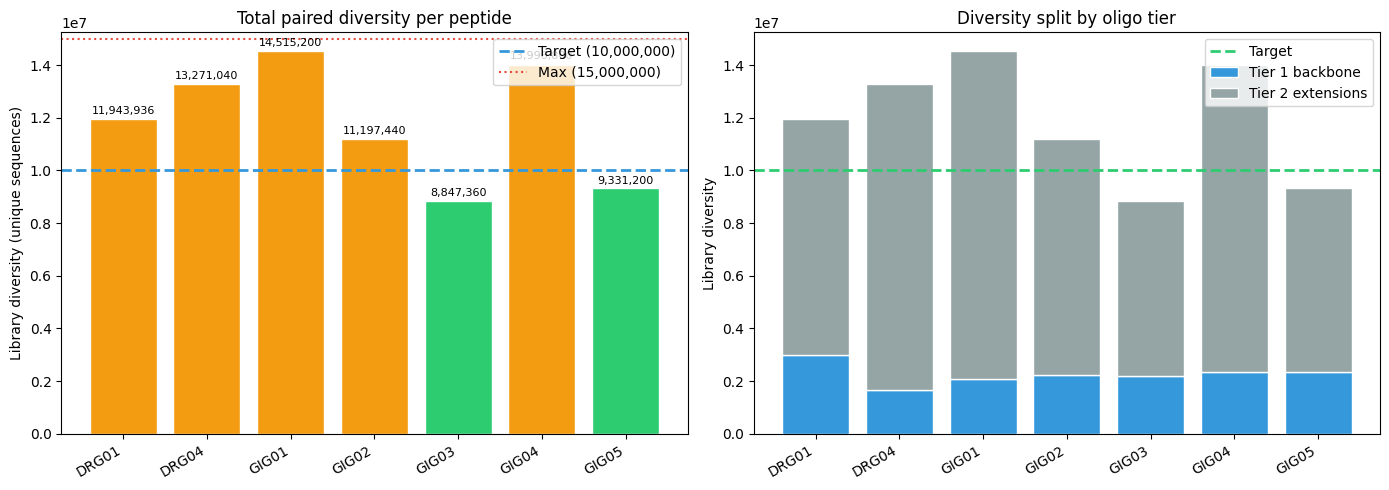

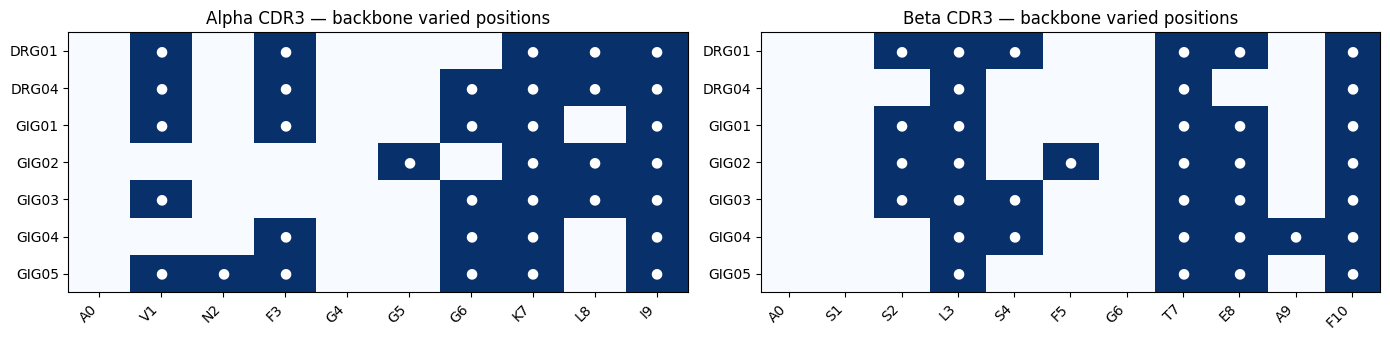

Codon efficiency (positions where IUPAC codon encodes unwanted AAs):
  DRG01: all codons at full efficiency
  DRG04: all codons at full efficiency
  GIG01: all codons at full efficiency
  GIG02: all codons at full efficiency
  GIG03: all codons at full efficiency
  GIG04: all codons at full efficiency
  GIG05: all codons at full efficiency
  No leaky codons across any peptide.


In [9]:
# ── 1. Summary table ─────────────────────────────────────────────────────
rows = []
for pep in PEPTIDES:
    pool     = POOLS[pep]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    total_div = sum(o['unique_diversity'] for o in pool)
    a_var = sorted(backbone['alpha_varied_pos']) if backbone else []
    b_var = sorted(backbone['beta_varied_pos'])  if backbone else []
    all_effs = [e for o in pool for e in o['codon_efficiency'].values()]
    rows.append({
        'peptide':        pep,
        'n_oligos':       len(pool),
        'backbone_div':   backbone['diversity'] if backbone else 0,
        'total_div':      total_div,
        'pct_target':     round(100 * total_div / TARGET_DIVERSITY, 1),
        'n_alpha_var':    len(a_var),
        'n_beta_var':     len(b_var),
        'alpha_var_pos':  a_var,
        'beta_var_pos':   b_var,
        'mean_codon_eff': round(np.mean(all_effs), 3) if all_effs else 1.0,
        'n_leaky_oligos': sum(1 for o in pool if o.get('is_leaky', False)),
    })

summary_df = pd.DataFrame(rows)
display(summary_df[['peptide','n_oligos','backbone_div','total_div','pct_target',
                     'n_alpha_var','n_beta_var','mean_codon_eff','n_leaky_oligos']])

# ── 2. Total diversity vs target / max ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(PEPTIDES))

ax = axes[0]
colors = ['#e74c3c' if v > MAX_DIVERSITY else
          '#f39c12' if v > TARGET_DIVERSITY * 1.1 else '#2ecc71'
          for v in summary_df['total_div']]
bars = ax.bar(x, summary_df['total_div'], color=colors, edgecolor='white')
ax.axhline(TARGET_DIVERSITY, color='#3498db', lw=2,   ls='--', label=f'Target ({TARGET_DIVERSITY:,})')
ax.axhline(MAX_DIVERSITY,    color='#e74c3c', lw=1.5, ls=':',  label=f'Max ({MAX_DIVERSITY:,})')
ax.set_xticks(x); ax.set_xticklabels(PEPTIDES, rotation=30, ha='right')
ax.set_ylabel('Library diversity (unique sequences)')
ax.set_title('Total paired diversity per peptide')
ax.legend()
for bar, val in zip(bars, summary_df['total_div']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

# ── 3. Stacked bar: backbone vs extension contributions ───────────────────
ax2 = axes[1]
bb  = summary_df['backbone_div'].values
ext = summary_df['total_div'].values - bb
ax2.bar(x, bb,  label='Tier 1 backbone',    color='#3498db', edgecolor='white')
ax2.bar(x, ext, bottom=bb, label='Tier 2 extensions', color='#95a5a6', edgecolor='white')
ax2.axhline(TARGET_DIVERSITY, color='#2ecc71', lw=2, ls='--', label='Target')
ax2.set_xticks(x); ax2.set_xticklabels(PEPTIDES, rotation=30, ha='right')
ax2.set_ylabel('Library diversity')
ax2.set_title('Diversity split by oligo tier')
ax2.legend()

plt.tight_layout()
plt.show()

# ── 4. Backbone varied-position heatmap (alpha and beta) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for chain, wt_seq, ax in [('alpha', WT_ALPHA, axes[0]), ('beta', WT_BETA, axes[1])]:
    n_pos = len(wt_seq)
    mat   = np.zeros((len(PEPTIDES), n_pos))
    for pi, pep in enumerate(PEPTIDES):
        bb = next((o for o in POOLS[pep] if o['oligo_type'] == 'tier1_backbone'), None)
        if bb:
            for p in bb[f'{chain}_varied_pos']:
                mat[pi, p] = 1
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_pos))
    ax.set_xticklabels([f'{aa}{i}' for i, aa in enumerate(wt_seq)], rotation=45, ha='right')
    ax.set_yticks(range(len(PEPTIDES))); ax.set_yticklabels(PEPTIDES)
    ax.set_title(f'{chain.capitalize()} CDR3 — backbone varied positions')
    for pi in range(len(PEPTIDES)):
        for po in range(n_pos):
            if mat[pi, po]:
                ax.text(po, pi, '●', ha='center', va='center', fontsize=10, color='white')

plt.tight_layout()
plt.show()

# ── 5. Codon efficiency report ────────────────────────────────────────────
print('Codon efficiency (positions where IUPAC codon encodes unwanted AAs):')
any_leaky = False
for pep in PEPTIDES:
    leaky_oligos = [o for o in POOLS[pep] if o.get('is_leaky', False)]
    if leaky_oligos:
        any_leaky = True
        for o in leaky_oligos:
            bad = {str(k): round(v, 2) for k, v in o['codon_efficiency'].items()
                   if v < EFFICIENCY_THRESH}
            print(f'  {o["oligo_id"]}: {bad}')
    else:
        print(f'  {pep}: all codons at full efficiency')
if not any_leaky:
    print('  No leaky codons across any peptide.')


## Visualise: Paired Oligos

One figure per peptide, **one panel per oligo**. The x-axis spans all 21 positions: alpha CDR3 (positions 0&ndash;9) on the left, beta CDR3 (0&ndash;10) on the right, separated by a dashed line.

- **&#9632; grey square** = WT residue encoded at this position
- **&#9679; coloured circle** = a non-WT amino acid the IUPAC codon encodes, coloured by chemistry (hydrophobic / polar / basic / acidic)
- **Shaded column** = variable position (codon encodes &gt; 1 AA); alpha shaded beige, beta shaded blue
- The **IUPAC triplet** chosen for each variable position is printed on the second line of its x-tick label

Each panel title shows the oligo id, its tier, and its diversity. Figures are saved as PDF and PNG (filenames tagged with `TIER1_FRAC` and `TOP_K`) into `OUT_DIR`.


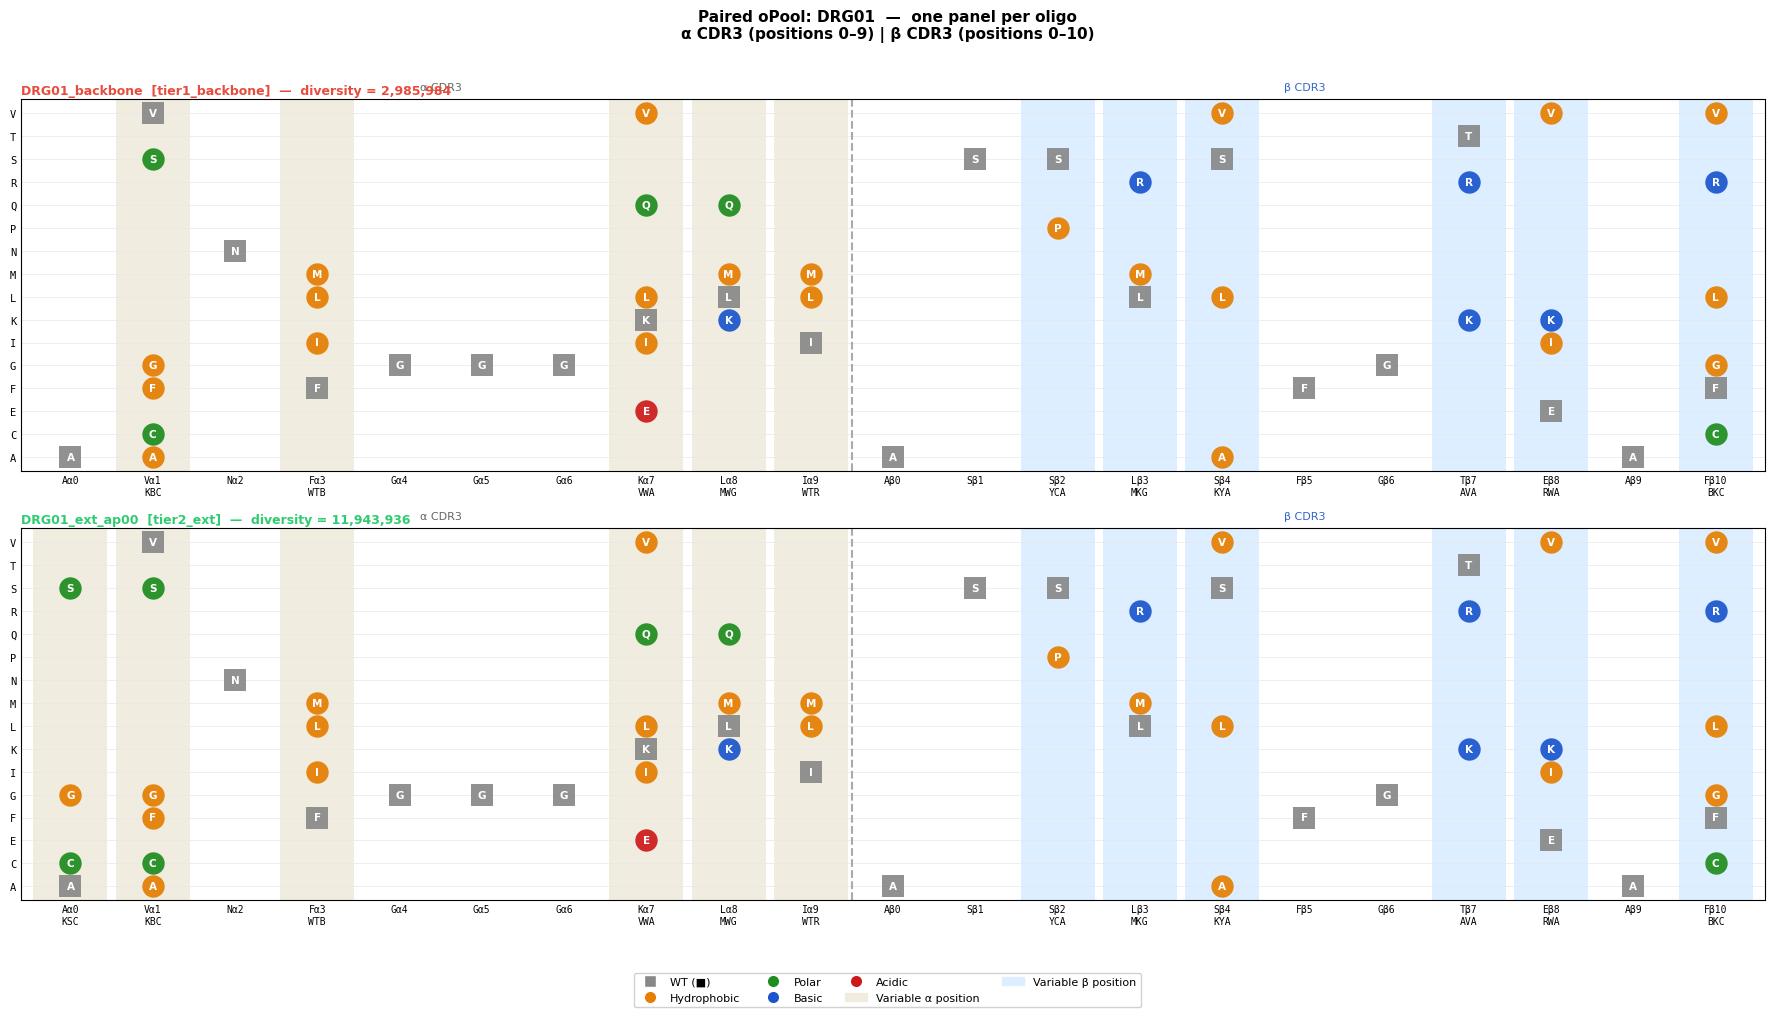

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG01_t0.33_tk2_per_oligo.pdf


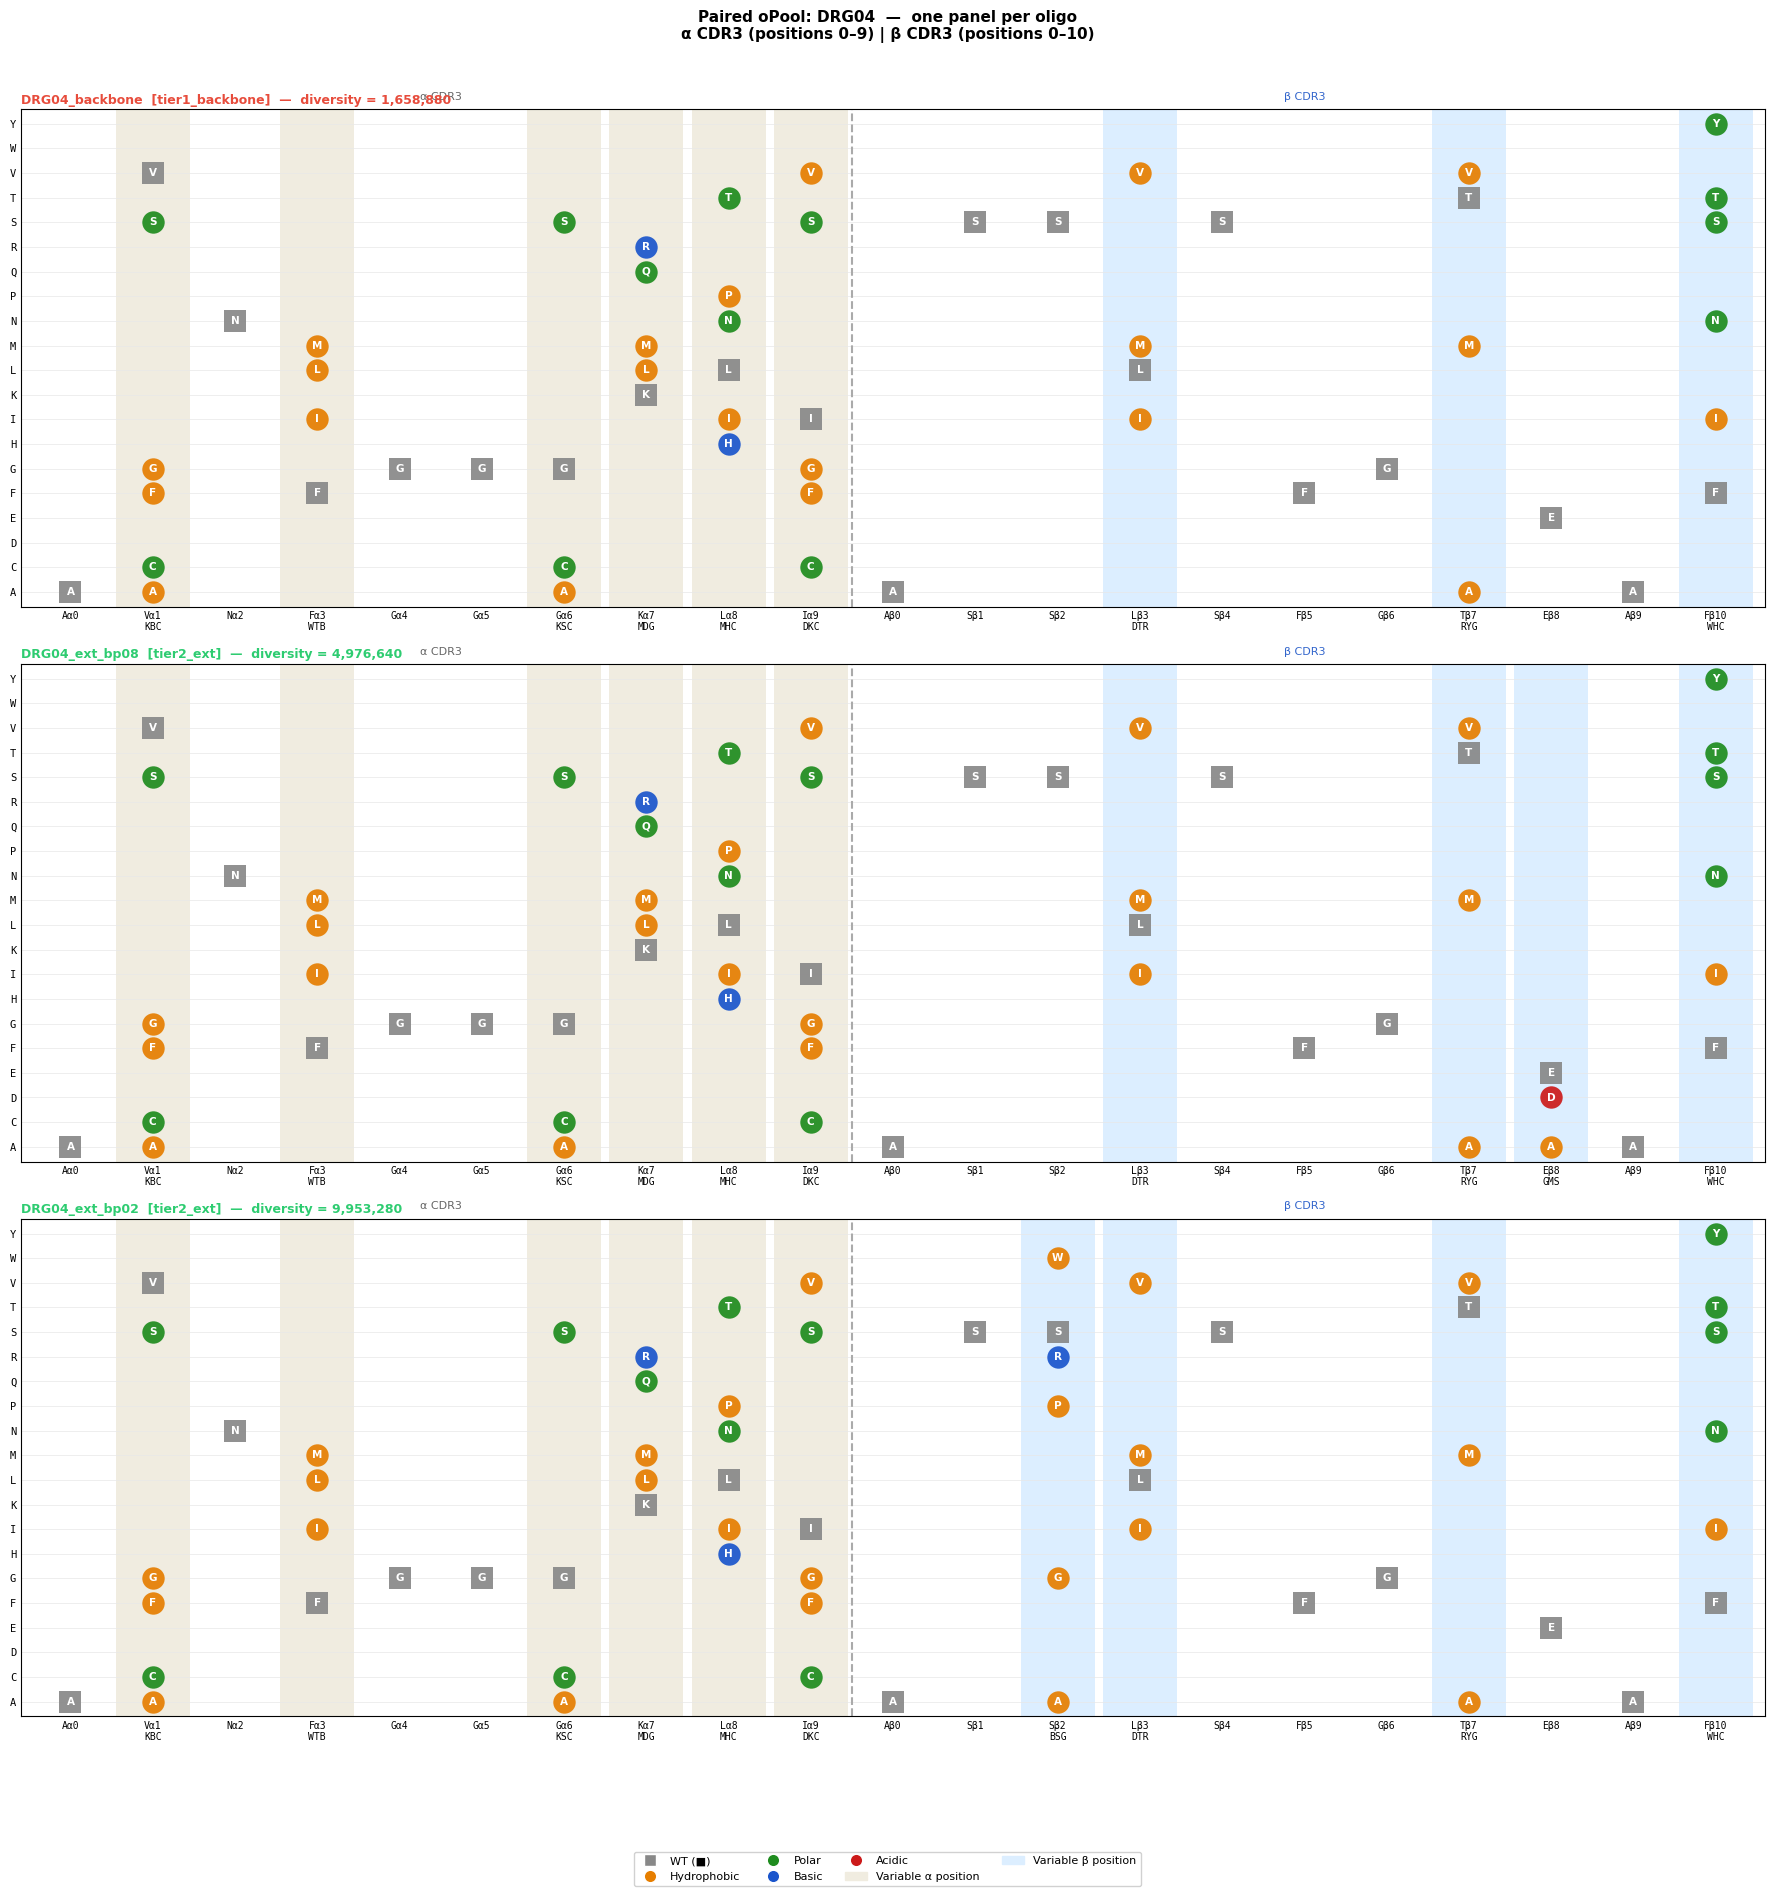

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG04_t0.33_tk2_per_oligo.pdf


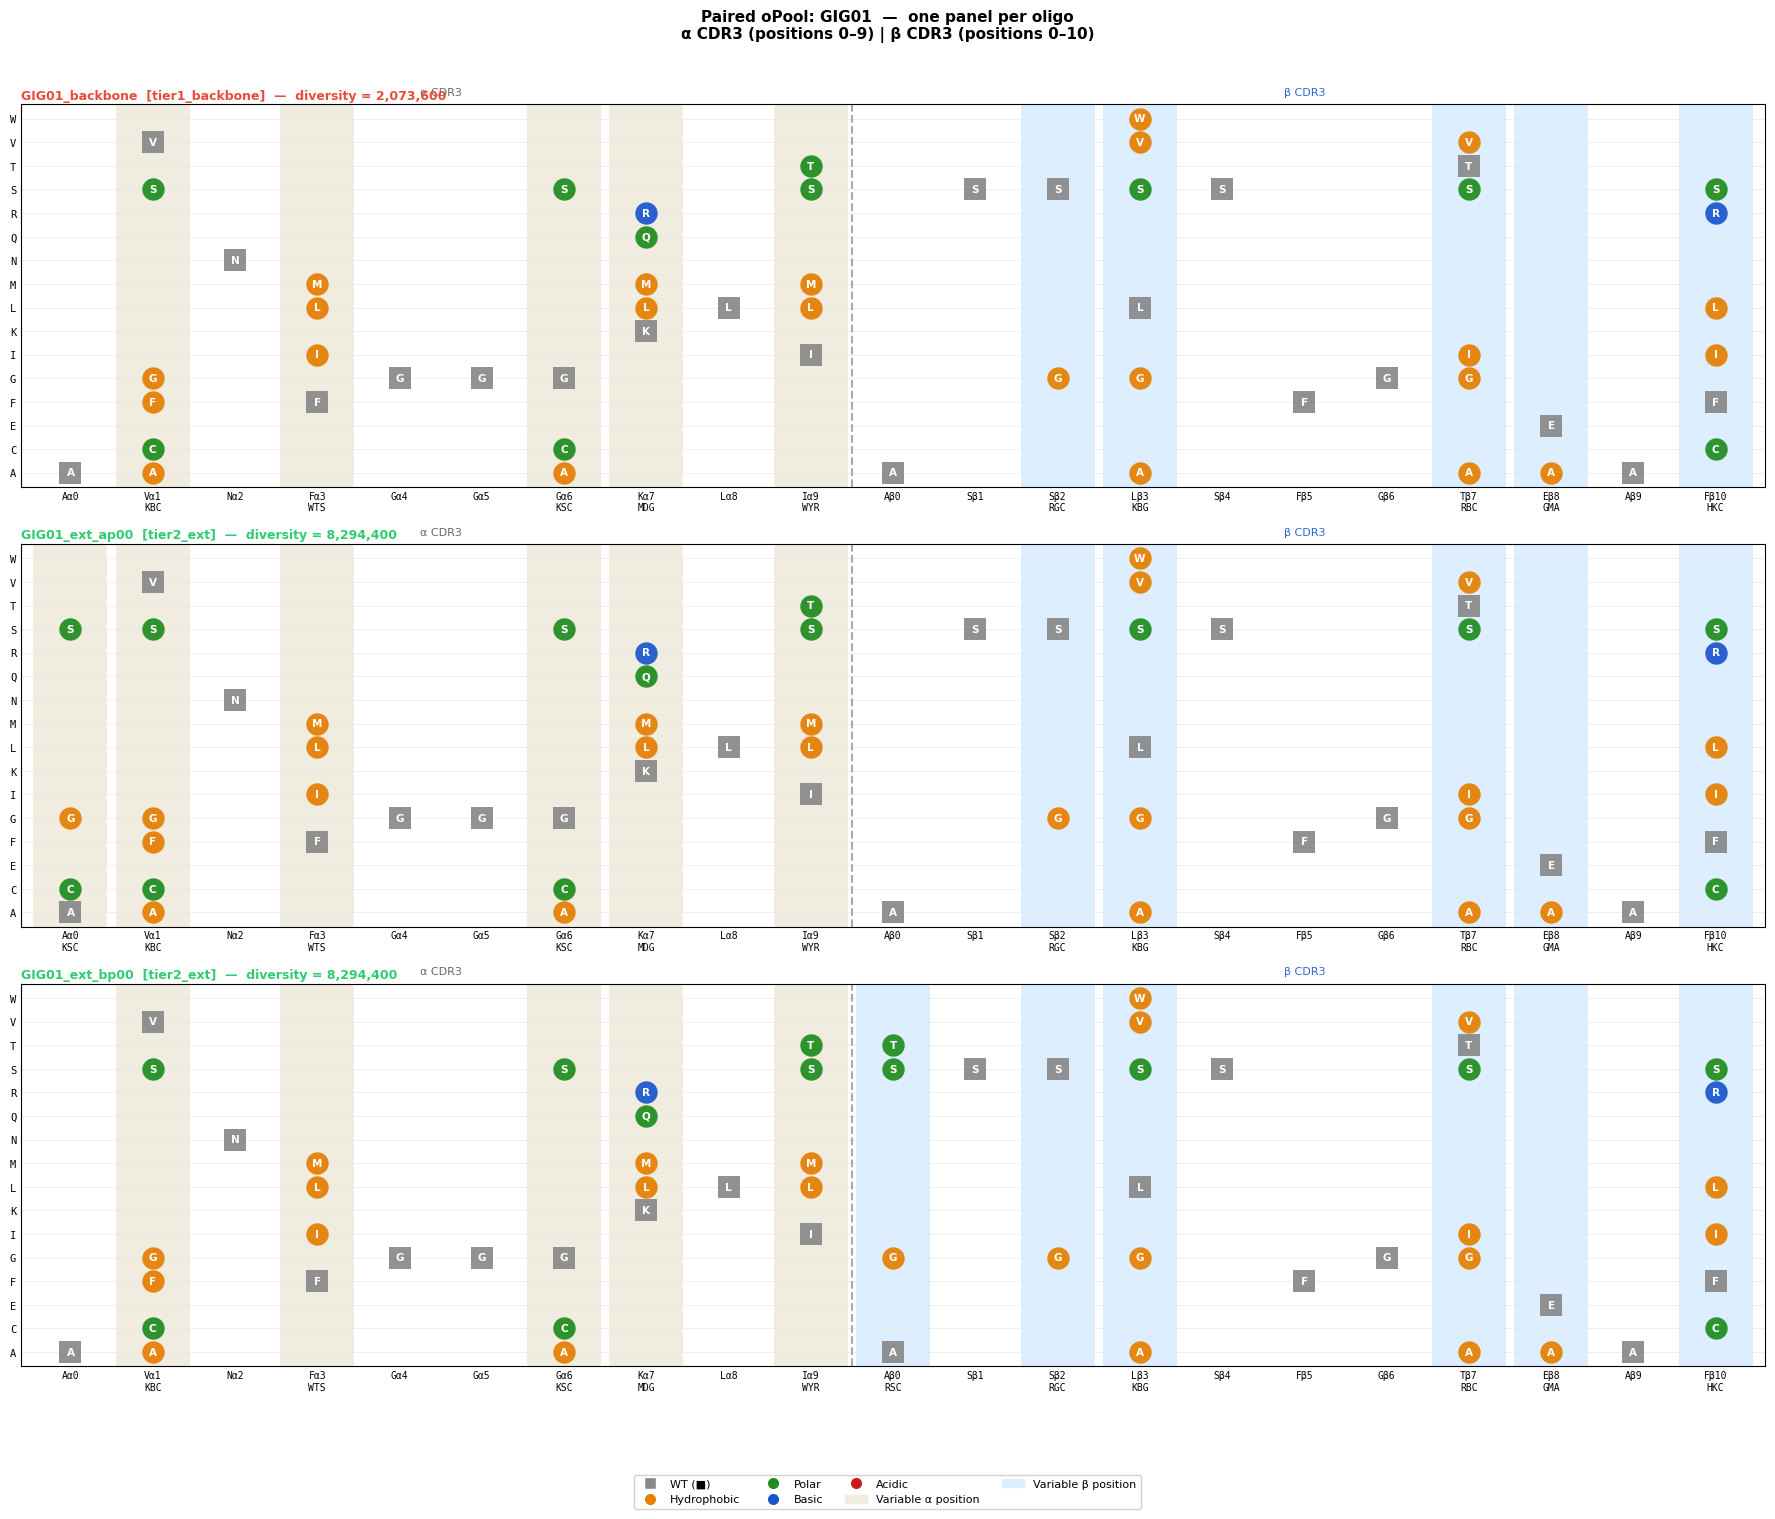

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG01_t0.33_tk2_per_oligo.pdf


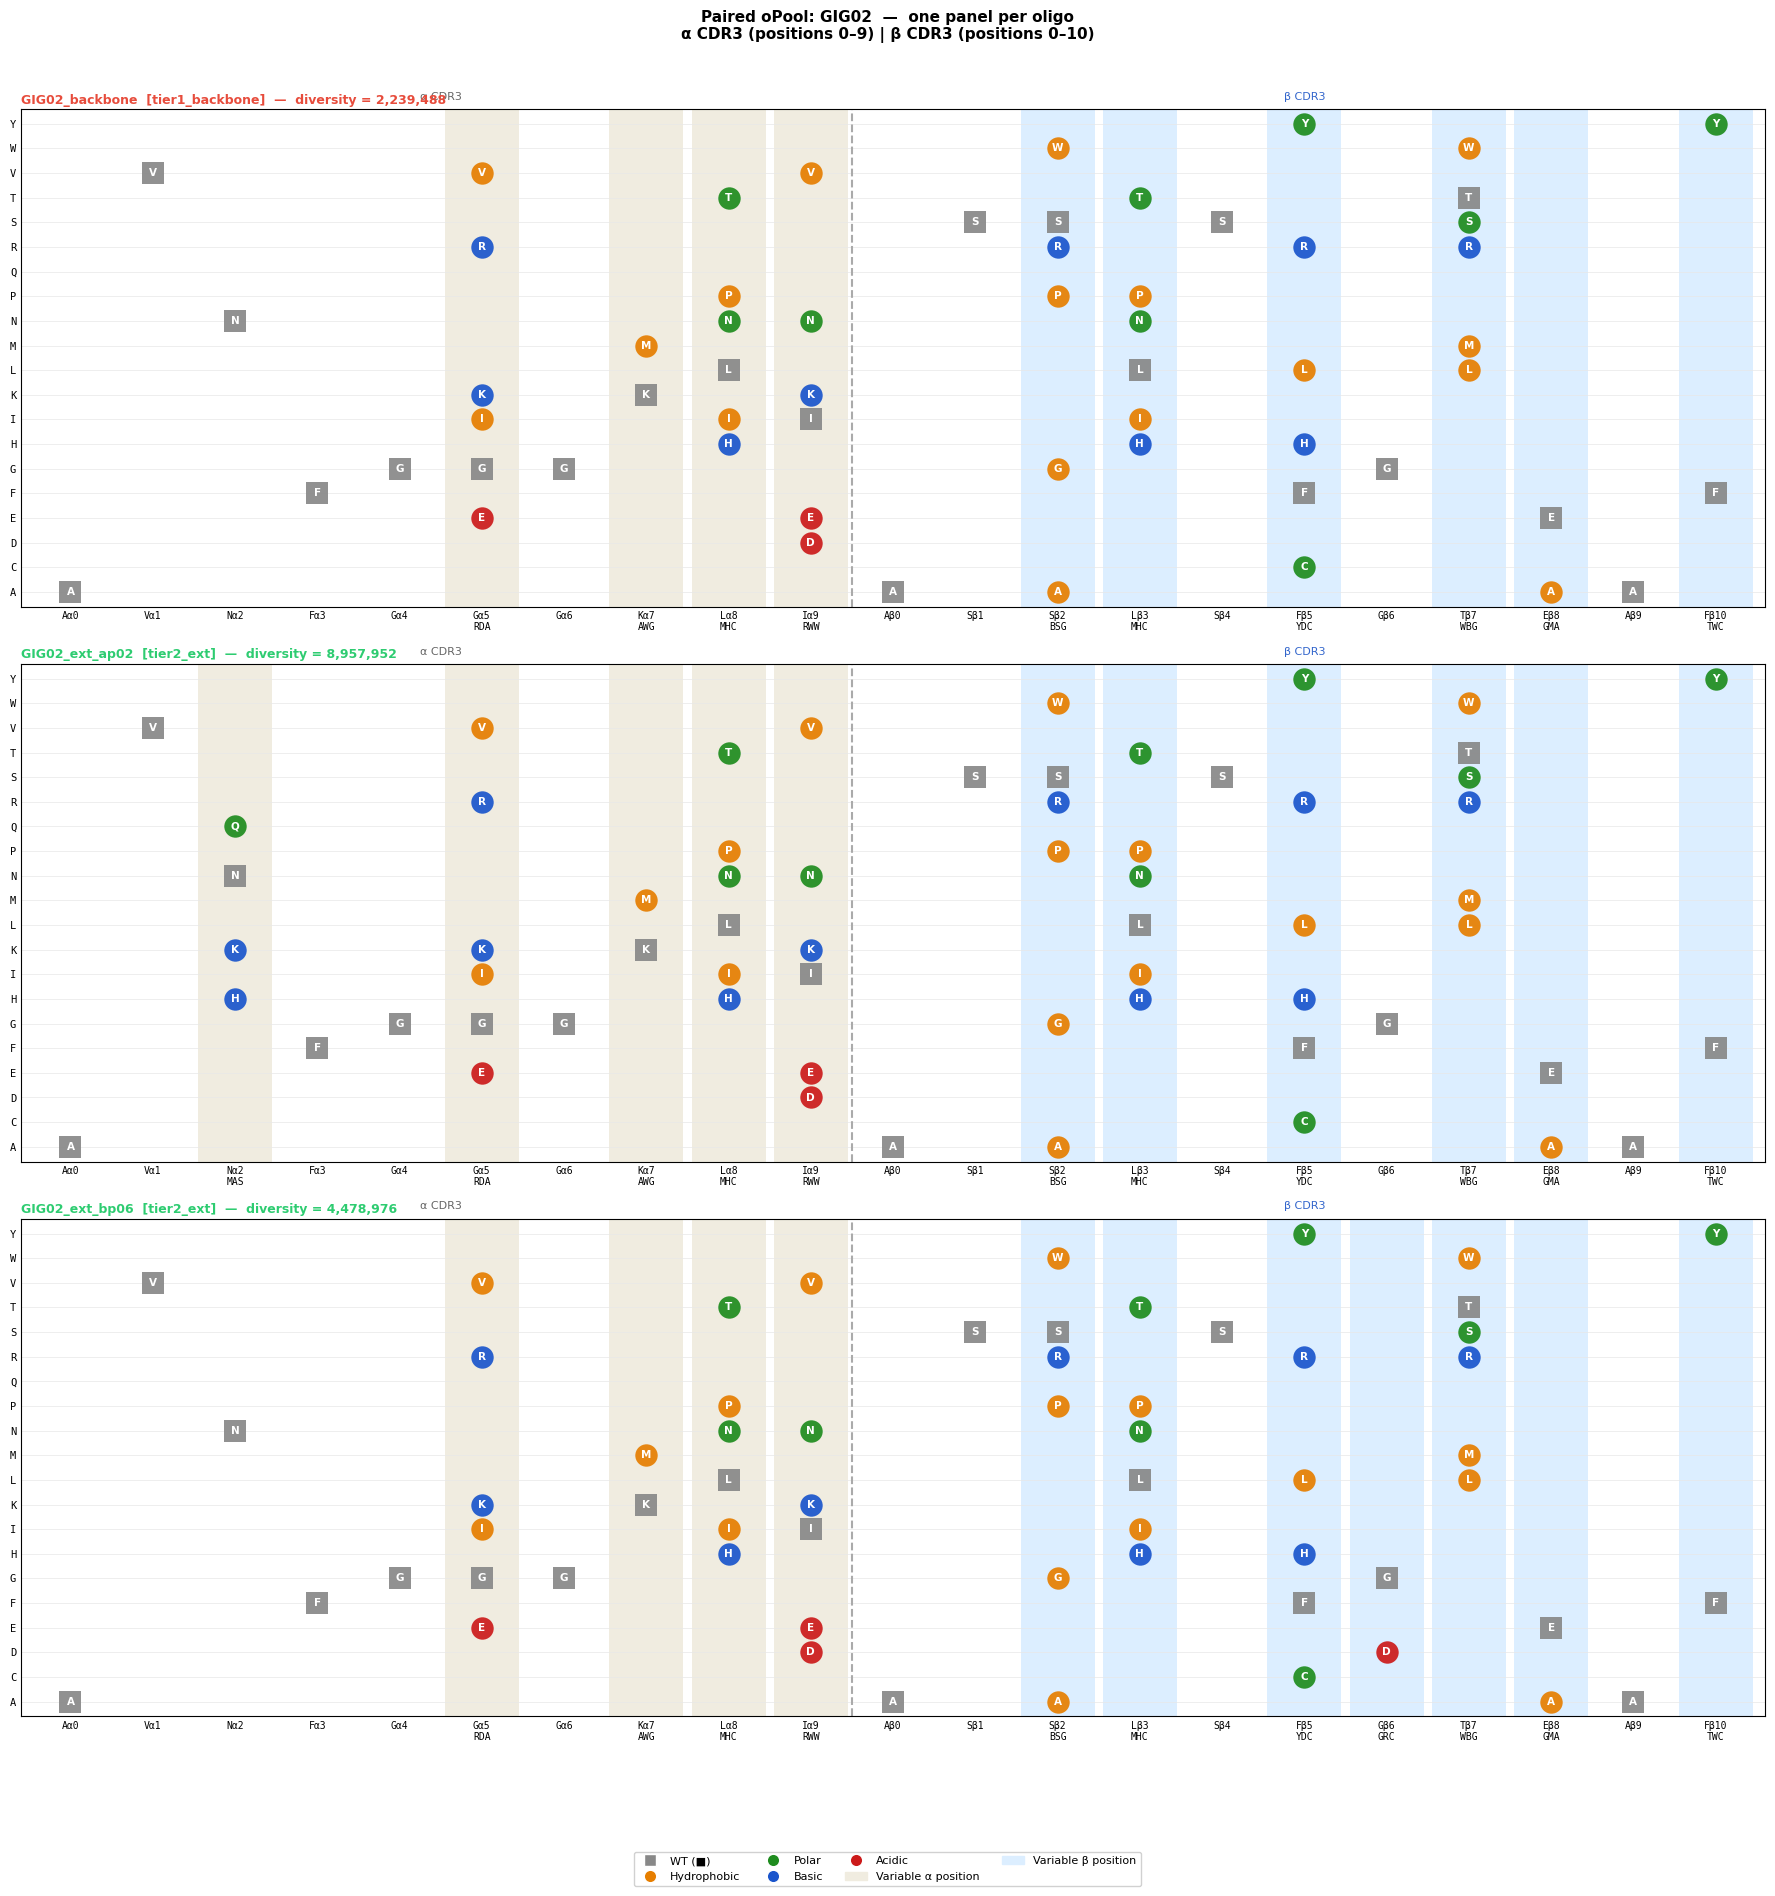

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG02_t0.33_tk2_per_oligo.pdf


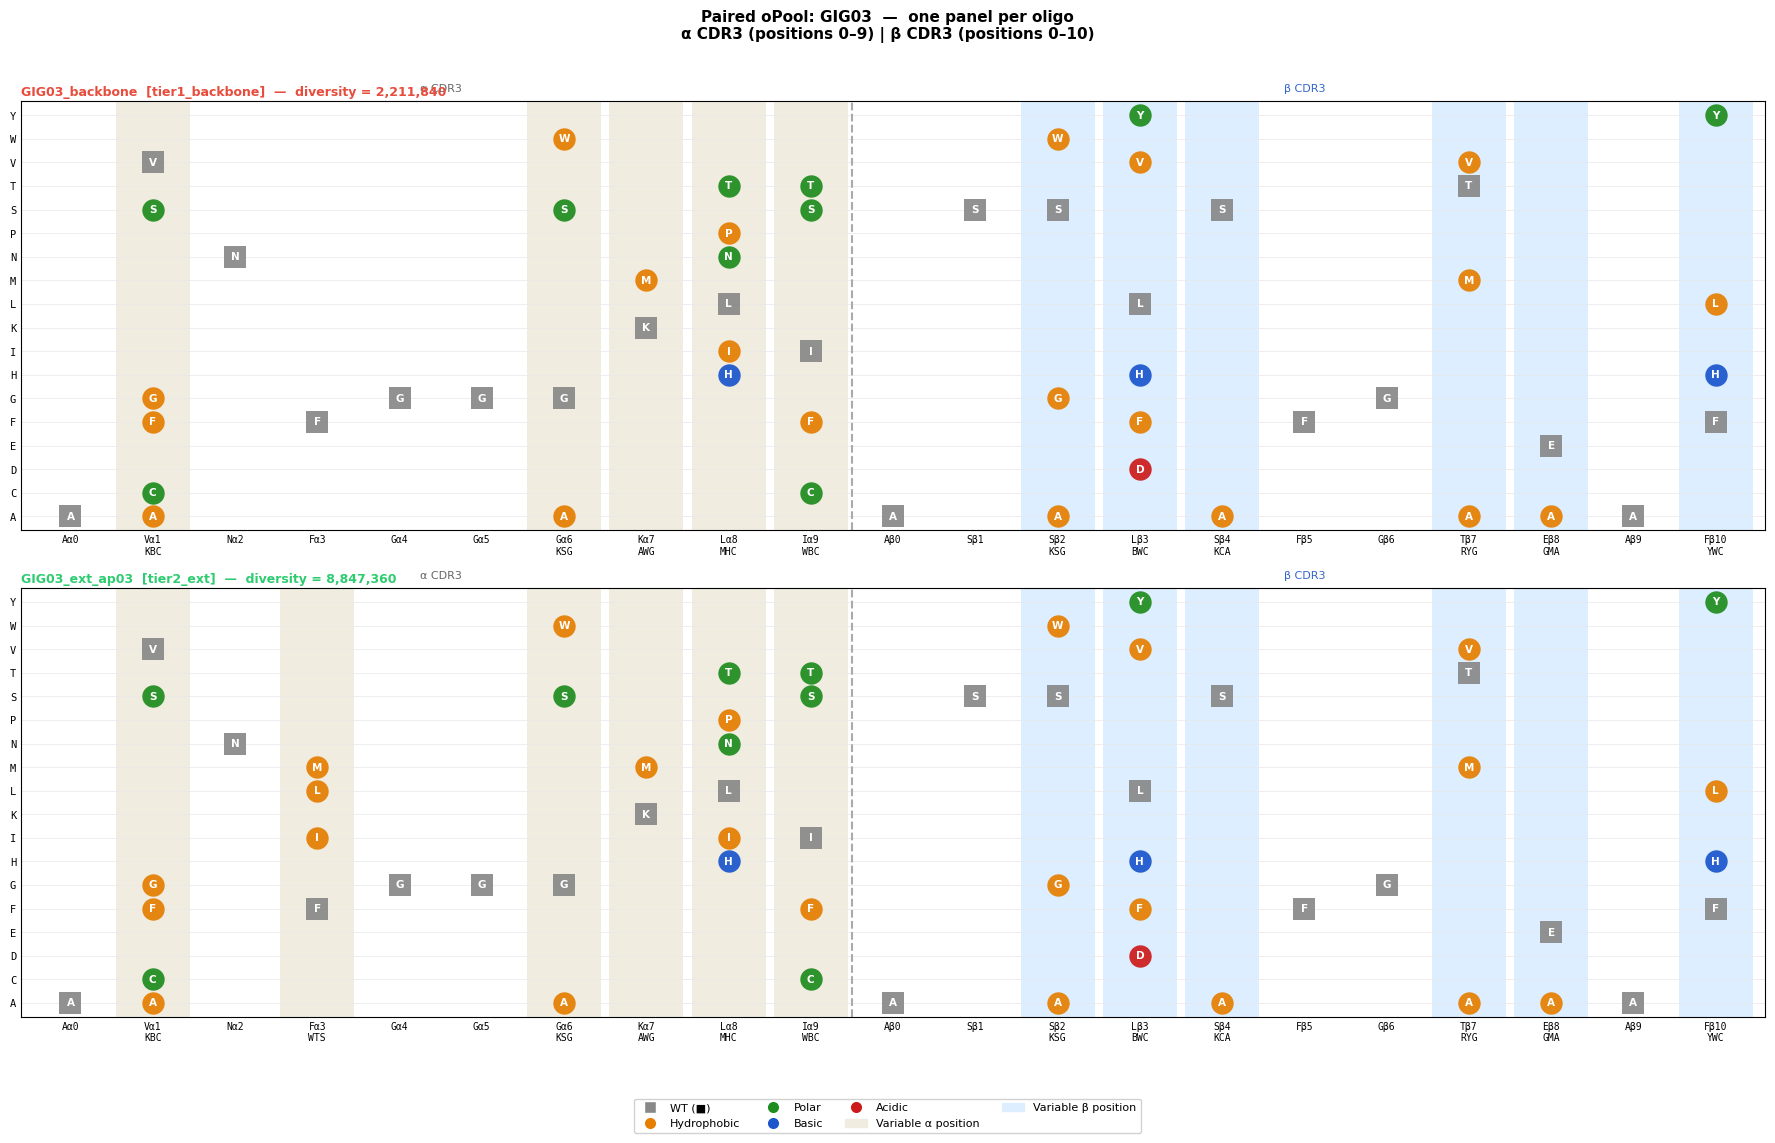

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG03_t0.33_tk2_per_oligo.pdf


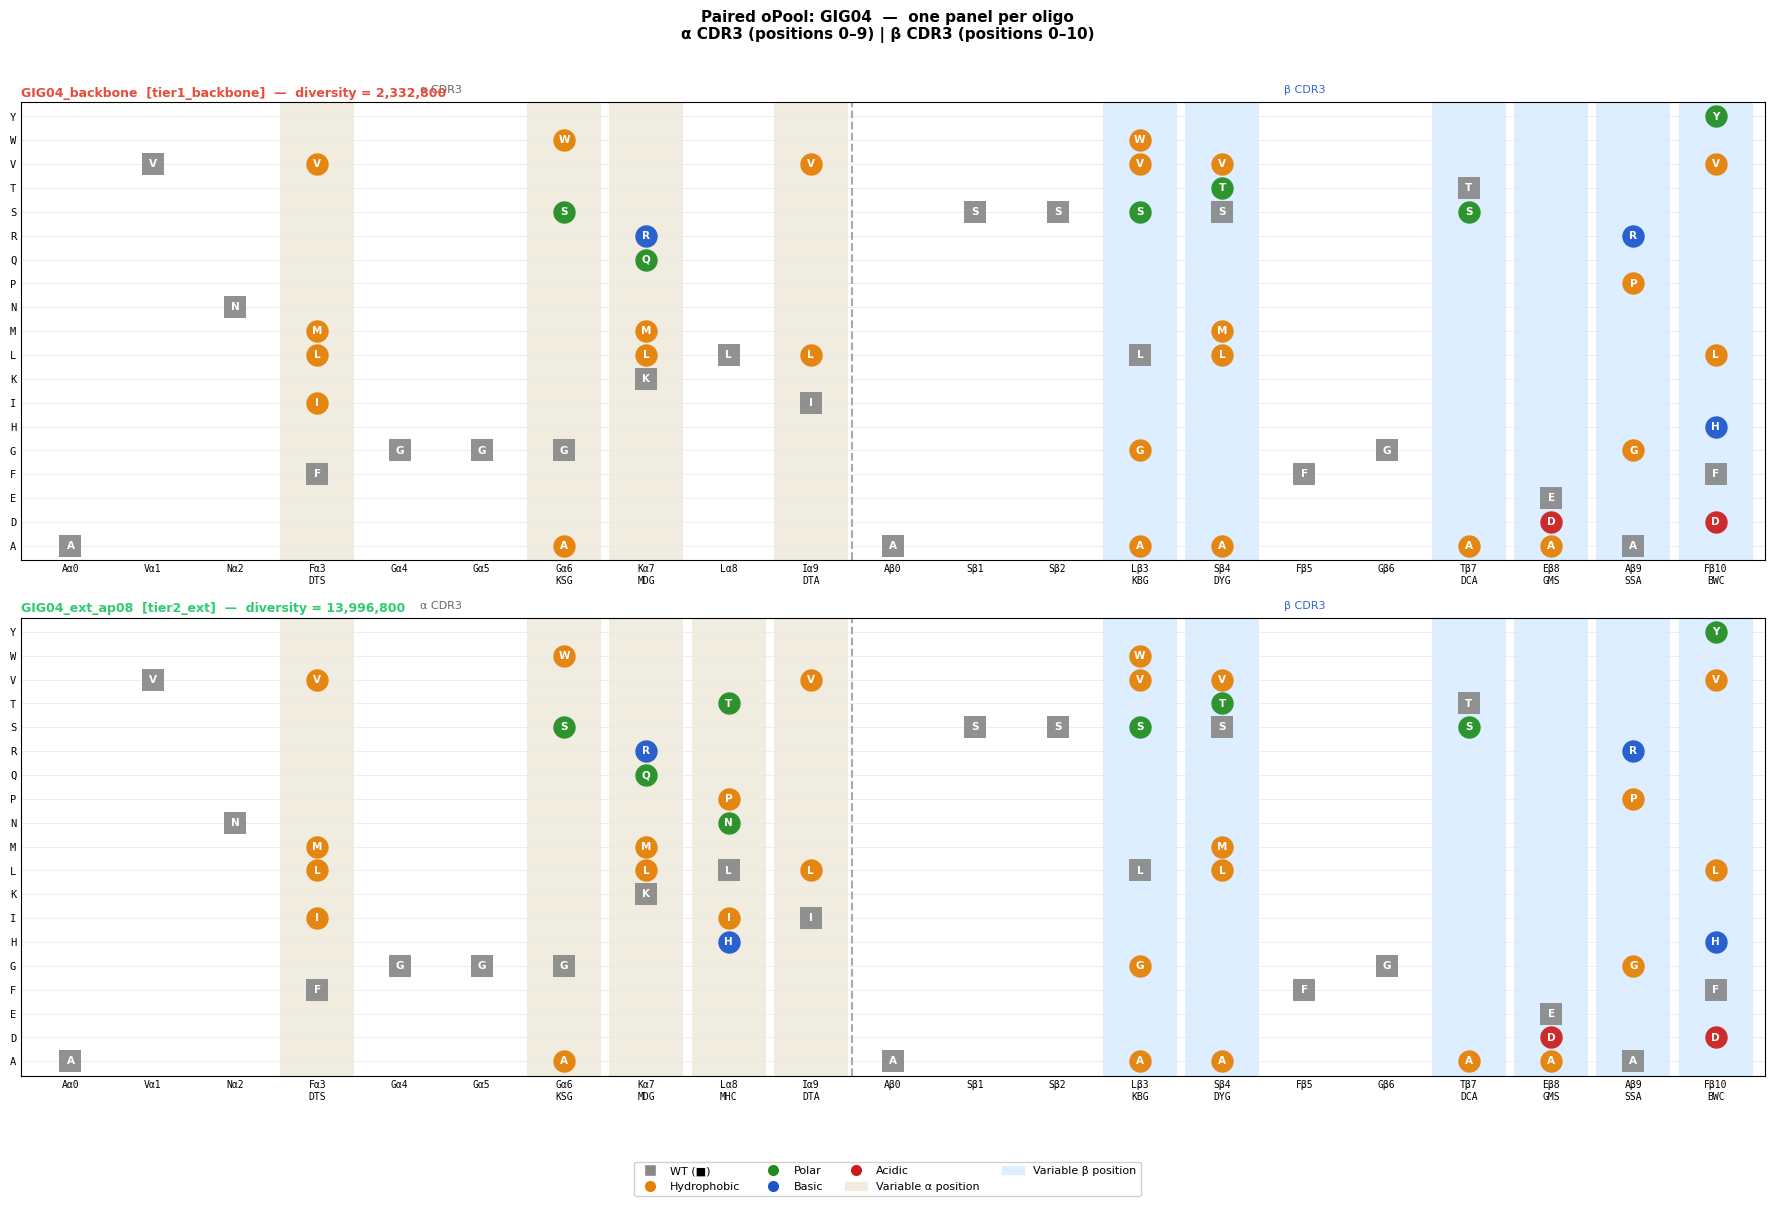

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG04_t0.33_tk2_per_oligo.pdf


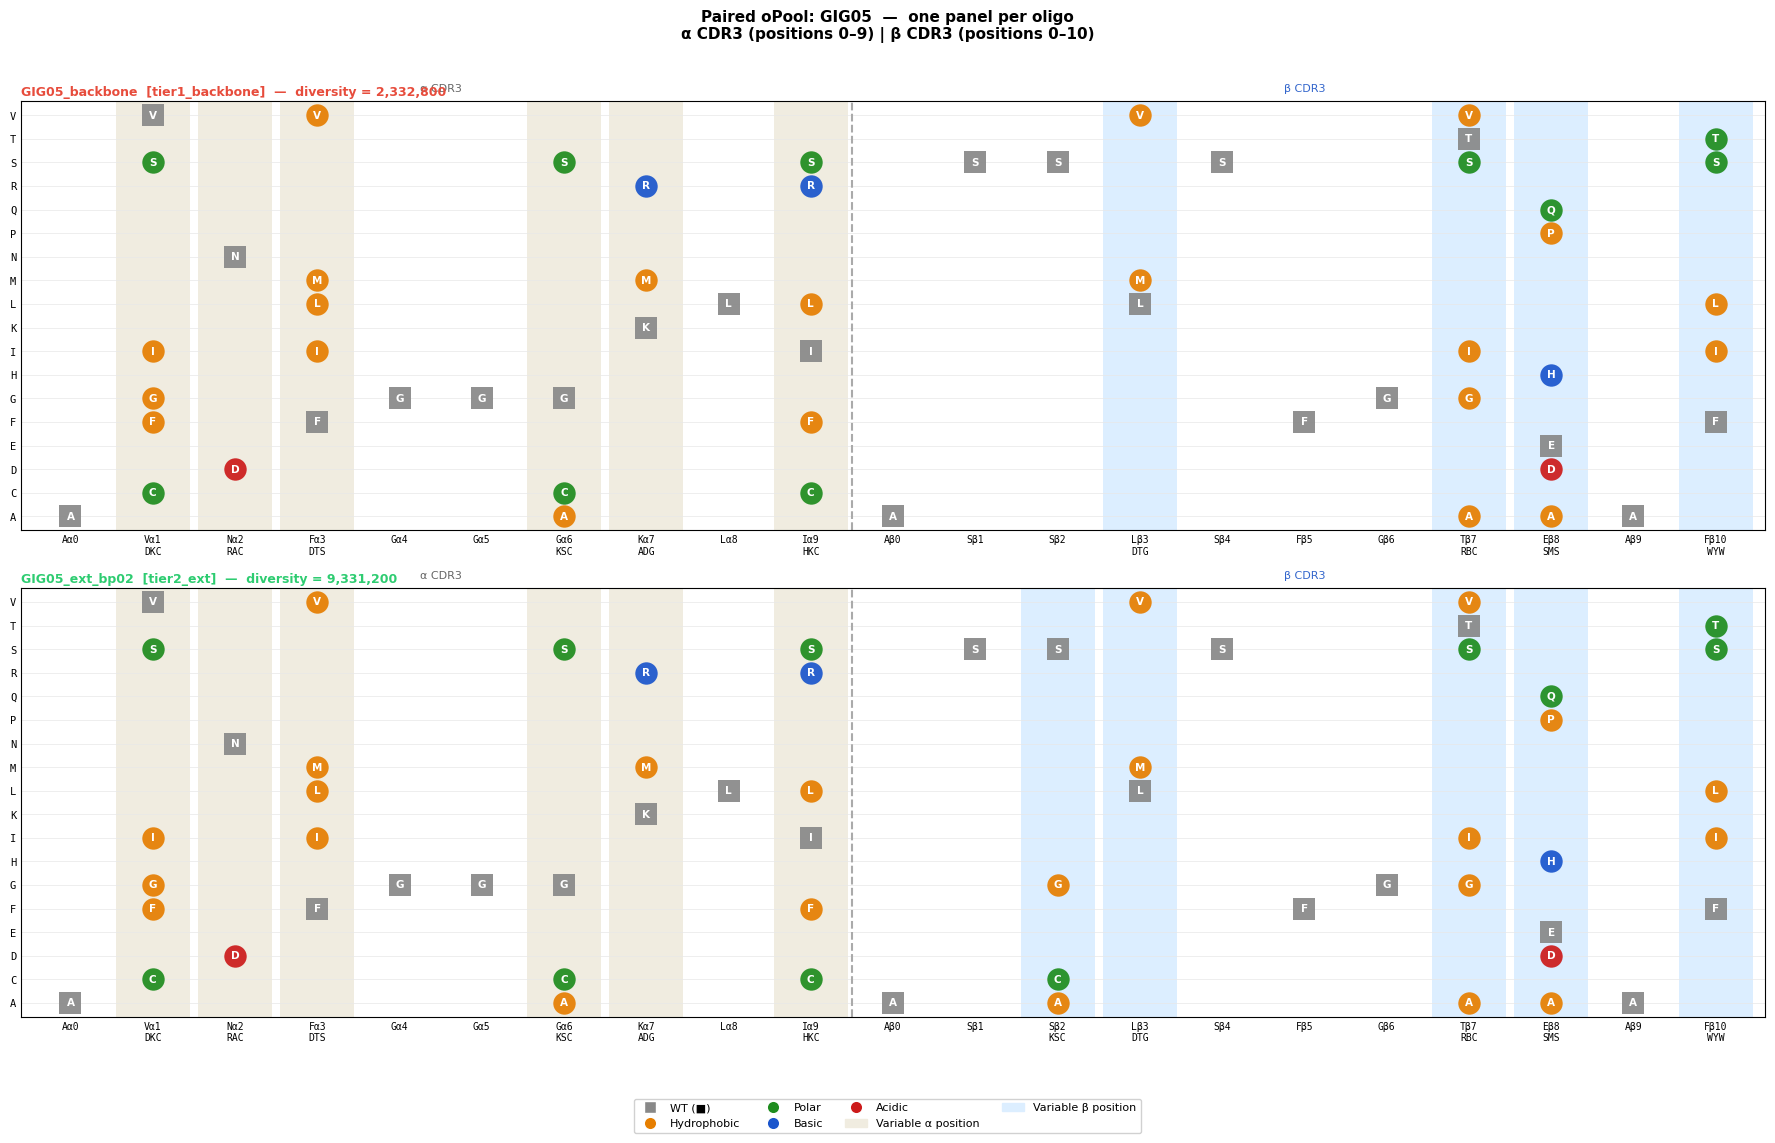

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG05_t0.33_tk2_per_oligo.pdf


In [10]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

AA_CHEM = {
    'A':'#e67e00','G':'#e67e00','V':'#e67e00','I':'#e67e00','L':'#e67e00',
    'M':'#e67e00','F':'#e67e00','W':'#e67e00','P':'#e67e00',
    'S':'#1e8c1e','T':'#1e8c1e','C':'#1e8c1e','Y':'#1e8c1e',
    'N':'#1e8c1e','Q':'#1e8c1e',
    'K':'#1a55cc','R':'#1a55cc','H':'#1a55cc',
    'D':'#cc1a1a','E':'#cc1a1a',
}
WT_COL = '#888888'
OLIGO_TYPE_COLOR = {'tier1_backbone': '#e74c3c', 'tier2_ext': '#2ecc71'}
SEP_X = ALPHA_LEN - 0.5   # vertical separator between alpha and beta sections


def plot_paired_pool(pep, pool):
    n_total = ALPHA_LEN + BETA_LEN   # 21 positions on x-axis

    all_aas = sorted({
        aa
        for o in pool
        for aas_dict in [o['alpha_position_aas'], o['beta_position_aas']]
        for aas in aas_dict.values()
        for aa in aas
    })
    aa_y   = {aa: i for i, aa in enumerate(all_aas)}
    n_aa   = len(all_aas)
    row_h  = max(3.0, n_aa * 0.32)

    n_oligos = len(pool)
    fig, axes = plt.subplots(n_oligos, 1,
                             figsize=(max(14, n_total * 0.85), row_h * n_oligos),
                             squeeze=False)

    for ax, oligo in zip(axes[:, 0], pool):
        # Shade variable positions
        for pos in range(ALPHA_LEN):
            if len(oligo['alpha_position_aas'][pos]) > 1:
                ax.axvspan(pos - 0.45, pos + 0.45, color='#f0ece0', zorder=0, lw=0)
        for pos in range(BETA_LEN):
            x = ALPHA_LEN + pos
            if len(oligo['beta_position_aas'][pos]) > 1:
                ax.axvspan(x - 0.45, x + 0.45, color='#dceeff', zorder=0, lw=0)

        # Chain separator
        ax.axvline(SEP_X, color='#aaaaaa', linewidth=1.5, linestyle='--', zorder=2)

        # Alpha positions
        for pos in range(ALPHA_LEN):
            wt_aa = WT_ALPHA[pos]
            for aa in sorted(oligo['alpha_position_aas'][pos]):
                color  = WT_COL if aa == wt_aa else AA_CHEM.get(aa, '#555555')
                marker = 's' if aa == wt_aa else 'o'
                ax.scatter(pos, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(pos, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        # Beta positions
        for pos in range(BETA_LEN):
            x = ALPHA_LEN + pos
            wt_aa = WT_BETA[pos]
            for aa in sorted(oligo['beta_position_aas'][pos]):
                color  = WT_COL if aa == wt_aa else AA_CHEM.get(aa, '#555555')
                marker = 's' if aa == wt_aa else 'o'
                ax.scatter(x, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(x, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        ax.set_xlim(-0.6, n_total - 0.4)
        ax.set_ylim(-0.6, n_aa - 0.4)
        ax.set_xticks(range(n_total))

        xlabels = []
        for i in range(ALPHA_LEN):
            base = f'{WT_ALPHA[i]}\u03b1{i}'
            if len(oligo['alpha_position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["alpha_iupac"][i]}')
            else:
                xlabels.append(base)
        for i in range(BETA_LEN):
            base = f'{WT_BETA[i]}\u03b2{i}'
            if len(oligo['beta_position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["beta_iupac"][i]}')
            else:
                xlabels.append(base)
        ax.set_xticklabels(xlabels, fontsize=7, fontfamily='monospace')

        ax.set_yticks(range(n_aa))
        ax.set_yticklabels(all_aas, fontsize=7.5, fontfamily='monospace')
        ax.tick_params(axis='x', length=0, pad=3)
        ax.tick_params(axis='y', length=0)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color='#e8e8e8', linewidth=0.5)

        # Chain labels
        ax.text(ALPHA_LEN / 2 - 0.5, n_aa - 0.1, '\u03b1 CDR3',
                ha='center', va='bottom', fontsize=8, color='#666666')
        ax.text(ALPHA_LEN + BETA_LEN / 2 - 0.5, n_aa - 0.1, '\u03b2 CDR3',
                ha='center', va='bottom', fontsize=8, color='#3366cc')

        otype = oligo['oligo_type']
        tc    = OLIGO_TYPE_COLOR.get(otype, '#555')
        ax.set_title(
            f"{oligo['oligo_id']}  [{otype}]  —  diversity = {oligo['diversity']:,}",
            fontsize=9, loc='left', pad=4, color=tc, fontweight='bold',
        )

    legend_handles = [
        mlines.Line2D([], [], marker='s', color='w', markerfacecolor=WT_COL, markersize=9, label='WT (\u25a0)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#e67e00', markersize=9, label='Hydrophobic'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1e8c1e', markersize=9, label='Polar'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1a55cc', markersize=9, label='Basic'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#cc1a1a', markersize=9, label='Acidic'),
        mpatches.Patch(color='#f0ece0', label='Variable \u03b1 position'),
        mpatches.Patch(color='#dceeff', label='Variable \u03b2 position'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               fontsize=8, bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    fig.suptitle(f'Paired oPool: {pep}  —  one panel per oligo\n'
                 f'\u03b1 CDR3 (positions 0\u20139) | \u03b2 CDR3 (positions 0\u201310)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.97])

    pdf = OUT_DIR / f'opool_paired_{pep}_t{TIER1_FRAC}_tk{TOP_K}_per_oligo.pdf'
    png = OUT_DIR / f'opool_paired_{pep}_t{TIER1_FRAC}_tk{TOP_K}_per_oligo.png'
    plt.savefig(pdf, bbox_inches='tight')
    plt.savefig(png, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved \u2192 {pdf}')


for pep in PEPTIDES:
    plot_paired_pool(pep, POOLS[pep])

## Export to CSV

Writes one CSV per peptide (`opool_paired_<pep>.csv`) listing every oligo (backbone + extensions). Columns include the alpha / beta / combined IUPAC DNA, the variable positions and their encoded AAs, per-oligo and cumulative diversity, mean codon efficiency, the **`full_length_frac`** (fraction of sequences with no in-frame stop &mdash; 1.0 by construction), and the `is_leaky` flag.

`paired_dna` = `alpha_dna + beta_dna` with **no adapters** &mdash; add the TCRAFT cloning adapters externally once finalised.

A combined IDT order sheet (`IDT_opool_paired_order.csv`) is also written with one row per oligo across all peptides (`Pool Name`, `Sequence Name`, `Sequence (no adapters)`).


In [11]:
def pool_to_df(pep, pool):
    rows, cumul = [], 0
    for o in pool:
        cumul += o['unique_diversity']
        alpha_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["alpha_position_aas"][p]))}]'
            for p in o['alpha_varied_pos']
        )
        beta_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["beta_position_aas"][p]))}]'
            for p in o['beta_varied_pos']
        )
        effs = [e for e in o['codon_efficiency'].values() if e < 1.0]
        rows.append({
            'oligo_id':               o['oligo_id'],
            'oligo_type':             o['oligo_type'],
            'alpha_dna':              o['alpha_dna'],
            'beta_dna':               o['beta_dna'],
            'paired_dna':             o['paired_dna'],
            'paired_dna_length_nt':   len(o['paired_dna']),
            'n_alpha_varied':         o['n_alpha_varied'],
            'n_beta_varied':          o['n_beta_varied'],
            'alpha_varied_positions': alpha_var,
            'beta_varied_positions':  beta_var,
            'diversity':              o['diversity'],
            'unique_diversity':       o['unique_diversity'],
            'cumulative_diversity':   cumul,
            'mean_codon_efficiency':  round(np.mean(effs), 3) if effs else 1.0,
            'full_length_frac':       round(o['full_length_frac'], 4),
            'is_leaky':               o.get('is_leaky', False),
        })
    return pd.DataFrame(rows)


idt_rows = []
for pep, pool in POOLS.items():
    df   = pool_to_df(pep, pool)
    path = OUT_DIR / f'opool_paired_{pep}.csv'
    df.to_csv(path, index=False)
    print(f'Wrote {path}  ({len(df)} oligos)')
    display(df[['oligo_id','oligo_type','alpha_dna','beta_dna',
                'n_alpha_varied','n_beta_varied','diversity','unique_diversity']])
    order = df[['oligo_id', 'paired_dna']].copy()
    order.insert(0, 'Pool Name', pep)
    idt_rows.append(order)

idt_df   = pd.concat(idt_rows, ignore_index=True)
idt_df   = idt_df.rename(columns={'oligo_id': 'Sequence Name', 'paired_dna': 'Sequence (no adapters)'})
idt_path = OUT_DIR / 'IDT_opool_paired_order.csv'
idt_df.to_csv(idt_path, index=False)
print(f'\nIDT order sheet (adapters TBD) → {idt_path}  ({len(idt_df)} oligos total)')
display(idt_df)

Wrote /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG01.csv  (2 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG01_backbone,tier1_backbone,GCAKBCAACWTBGGAGGAGGAVWAMWGWTR,GCAAGCYCAMKGKYATTCGGAAVARWAGCABKC,5,6,2985984,2985984
1,DRG01_ext_ap00,tier2_ext,KSCKBCAACWTBGGAGGAGGAVWAMWGWTR,GCAAGCYCAMKGKYATTCGGAAVARWAGCABKC,6,6,11943936,8957952


Wrote /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG04.csv  (3 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG04_backbone,tier1_backbone,GCAKBCAACWTBGGAGGAKSCMDGMHCDKC,GCAAGCAGCDTRAGCTTCGGARYGGAAGCAWHC,6,3,1658880,1658880
1,DRG04_ext_bp08,tier2_ext,GCAKBCAACWTBGGAGGAKSCMDGMHCDKC,GCAAGCAGCDTRAGCTTCGGARYGGMSGCAWHC,6,4,4976640,3317760
2,DRG04_ext_bp02,tier2_ext,GCAKBCAACWTBGGAGGAKSCMDGMHCDKC,GCAAGCBSGDTRAGCTTCGGARYGGAAGCAWHC,6,4,9953280,8294400


Wrote /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG01.csv  (3 oligos)


...

,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG04_backbone,tier1_backbone,GCAGTAAACDTSGGAGGAKSGMDGCTADTA,GCAAGCAGCKBGDYGTTCGGADCAGMSSSABWC,4,6,2332800,2332800
1,GIG04_ext_ap08,tier2_ext,GCAGTAAACDTSGGAGGAKSGMDGMHCDTA,GCAAGCAGCKBGDYGTTCGGADCAGMSSSABWC,5,6,13996800,11664000


Wrote /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG05.csv  (2 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG05_backbone,tier1_backbone,GCADKCRACDTSGGAGGAKSCADGCTAHKC,GCAAGCAGCDTGAGCTTCGGARBCSMSGCAWYW,6,4,2332800,2332800
1,GIG05_ext_bp02,tier2_ext,GCADKCRACDTSGGAGGAKSCADGCTAHKC,GCAAGCKSCDTGAGCTTCGGARBCSMSGCAWYW,6,5,9331200,6998400



IDT order sheet (adapters TBD) → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/IDT_opool_paired_order.csv  (17 oligos total)


,Pool Name,Sequence Name,Sequence (no adapters)
0,DRG01,DRG01_backbone,GCAKBCAACWTBGGAGGAGGAVWAMWGWTRGCAAGCYCAMKGKYAT...
1,DRG01,DRG01_ext_ap00,KSCKBCAACWTBGGAGGAGGAVWAMWGWTRGCAAGCYCAMKGKYAT...
2,DRG04,DRG04_backbone,GCAKBCAACWTBGGAGGAKSCMDGMHCDKCGCAAGCAGCDTRAGCT...
3,DRG04,DRG04_ext_bp08,GCAKBCAACWTBGGAGGAKSCMDGMHCDKCGCAAGCAGCDTRAGCT...
4,DRG04,DRG04_ext_bp02,GCAKBCAACWTBGGAGGAKSCMDGMHCDKCGCAAGCBSGDTRAGCT...
5,GIG01,GIG01_backbone,GCAKBCAACWTSGGAGGAKSCMDGCTAWYRGCAAGCRGCKBGAGCT...
6,GIG01,GIG01_ext_ap00,KSCKBCAACWTSGGAGGAKSCMDGCTAWYRGCAAGCRGCKBGAGCT...
7,GIG01,GIG01_ext_bp00,GCAKBCAACWTSGGAGGAKSCMDGCTAWYRRSCAGCRGCKBGAGCT...
8,GIG02,GIG02_backbone,GCAGTAAACTTCGGARDAGGAAWGMHCRWWGCAAGCBSGMHCAGCY...
9,GIG02,GIG02_ext_ap02,GCAGTAMASTTCGGARDAGGAAWGMHCRWWGCAAGCBSGMHCAGCY...
